### Úvod a príprava dát

### Nacitanie datasetu byt

In [9]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# 1. Načítanie JSON súboru
with open("data.json", "r") as file:
    json_data = json.load(file)

# 2. Extrahovanie sekcie "data"
df = pd.json_normalize(json_data["data"])

# 3. Premenovanie stĺpcov pre lepšiu čitateľnosť
df.columns = df.columns.str.replace(r"\.", "_", regex=True)

# 4. Prevod timestampu na datetime formát
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# 5. Nastavenie časového indexu
df.set_index('timestamp', inplace=True)

# 6. Hodinová agregácia (napr. priemer)
df = df.resample('1h').mean()

# 7. Zobrazenie prvých riadkov z hodinovo agregovaných dát
print(df.tail())

                           U_L1      I_L1         P_L1        Q_L1
timestamp                                                         
2024-11-25 05:00:00  241.875683  1.899683   376.167333 -157.742150
2024-11-25 06:00:00  242.101150  2.517483   538.411867  -83.347750
2024-11-25 07:00:00  242.210167  1.812800   276.782950  110.196817
2024-11-25 08:00:00  241.571183  5.723533  1122.427583  380.538150
2024-11-25 09:00:00  241.406000  2.858000   363.827000  380.706000


### Nacitanie datasetu dom

In [11]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# 1. Načítanie JSON súboru
with open("data2.json", "r") as file:
    json_data2 = json.load(file)

# 2. Extrahovanie sekcie "data"
df2 = pd.json_normalize(json_data2["data"])

# 3. Premenovanie stĺpcov pre lepšiu čitateľnosť
df2.columns = df2.columns.str.replace(r"\.", "_", regex=True)

# 4. Prevod timestampu na datetime formát
df2['timestamp'] = pd.to_datetime(df2['timestamp'], unit='s')

# 5. Nastavenie časového indexu
df2.set_index('timestamp', inplace=True)

# 6. Hodinová agregácia (napr. priemer)
df2 = df2.resample('1h').mean()

# 7. Zobrazenie prvých riadkov z hodinovo agregovaných dát
print(df2.tail())


                           U_L1        U_L2        U_L3  U_cumulative  \
timestamp                                                               
2024-11-25 05:00:00  243.024067  244.675467  235.729450    241.143050   
2024-11-25 06:00:00  245.241050  245.588800  239.173983    243.334667   
2024-11-25 07:00:00  245.807700  245.210783  241.104100    244.040817   
2024-11-25 08:00:00  243.456817  246.216533  240.537400    243.403633   
2024-11-25 09:00:00  244.010000  243.160000  238.323000    241.831000   

                         I_L1      I_L2      I_L3  I_cumulative       P_L1  \
timestamp                                                                    
2024-11-25 05:00:00  0.447417  0.378317  0.213667      1.039400  53.797383   
2024-11-25 06:00:00  0.422050  0.413767  0.149733      0.985550  42.064467   
2024-11-25 07:00:00  0.421483  0.358733  0.149550      0.929767  42.364467   
2024-11-25 08:00:00  0.418917  0.360300  0.304233      1.083450  41.936767   
2024-11-25 09:00:00 

Funkcia clip_extremes_inplace orezáva extrémne hodnoty v každom stĺpci
podľa zadaných kvantilov (napr. 0.5 % a 99.5 %). Hodnoty pod dolným kvantilom nahradí dolným limitom
a hodnoty nad horným kvantilom horným limitom. 

In [13]:
def clip_extremes_inplace(df, lower_q=0.005, upper_q=0.995):
    for col in df.columns:
        lower = df[col].quantile(lower_q)
        upper = df[col].quantile(upper_q)
        df[col] = df[col].clip(lower=lower, upper=upper)


In [15]:
clip_extremes_inplace(df2)
clip_extremes_inplace(df)

In [17]:
df.rename(columns=lambda col: col.replace('_L1', '_cumulative') if col.endswith('_L1') else col, inplace=True)

Funkcia fill_rows_from_previous_day vypĺňa chýbajúce hodnoty v riadkoch podľa zadaného stĺpca tým
že ich nahradí hodnotami z rovnakého času predchádzajúceho dňa. Pre každý NaN v stĺpci
P_cumulative skopíruje celý riadok z rovnakého času o deň dozadu

In [19]:
import pandas as pd

def fill_rows_from_previous_day(df, target_column='P_cumulative'):
    df_filled = df.copy()
    for timestamp in df.index:
        if pd.isna(df_filled.loc[timestamp, target_column]):
            prev_day_timestamp = timestamp - pd.Timedelta(days=1)
            if prev_day_timestamp in df_filled.index:
                df_filled.loc[timestamp] = df_filled.loc[prev_day_timestamp]
    return df_filled


In [21]:
df2 = fill_rows_from_previous_day(df2)
df = fill_rows_from_previous_day(df)

### Vytvorenie novych atributov

In [28]:


df['hour'] = df.index.hour # hodina v ramci dna
df['day_of_week'] = df.index.dayofweek  # 0 = pondelok, 6 = nedeľa
df['day'] = df.index.day # den
df['month'] = df.index.month # mesiac
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)  # sobota alebo nedeľa = 1


In [30]:

df2['hour'] = df2.index.hour
df2['day_of_week'] = df2.index.dayofweek  # 0 = pondelok, 6 = nedeľa
df2['day'] = df2.index.day
df2['month'] = df2.index.month
df2['is_weekend'] = df2['day_of_week'].isin([5, 6]).astype(int)  # víkend = 1


In [32]:
df['lag_1'] = df['P_cumulative'].shift(1) # lag1 - hodnoty cielovej premenej z pred hodiny
df['lag_24'] = df['P_cumulative'].shift(24) # lag2 - hodnoty cielovej premenej z pred 24 hodin



In [34]:
df2['lag_1'] = df2['P_cumulative'].shift(1)
df2['lag_24'] = df2['P_cumulative'].shift(24)


In [36]:
df2.drop(columns=[
    'U_L1', 'U_L2', 'U_L3',
    'I_L1', 'I_L2', 'I_L3',
    'P_L1', 'P_L2', 'P_L3',
    'Q_L1', 'Q_L2', 'Q_L3'
], inplace=True)


In [38]:
for col in df2.columns:
    print(col)

U_cumulative
I_cumulative
P_cumulative
Q_cumulative
hour
day_of_week
day
month
is_weekend
lag_1
lag_24


# Začiatok modelovania
## Upozornenie: Po spustení trvá približne minútu, kým sa zobrazia výsledky.

###  Úvod

Predikcia pomocou **XGBoost**.

Používame prístup s **posuvným tréningovým oknom (sliding window)** , model sa trénuje na určitom počte dní (napr. 7, 14 alebo 21 dní). Tréningové okno sa postupne **posúva**, čiže skúšame viacero počiatočných dní. Pre každý z nich model predikuje nasledujúci deň (24 hodín), pričom medzi tréningom a predikciou je **1-dňová medzera (gap)**.

**Cieľom prvej fázy je nájsť kombináciu:**
- najlepšieho tréningového intervalu (tzn. v ktorých dňoch sa oplatí trénovať),
- a najlepších parametrov modelu, ktoré vedú k čo najnižšej chybe predikcie.

Model **XGBoost** ladíme pomocou techniky **GridSearch**, kde skúšame rôzne kombinácie hyperparametrov:
- `n_estimators` – počet stromov,
- `learning_rate` – rýchlosť učenia,
- `max_depth` – maximálna hĺbka stromu.

Presnosť modelu hodnotíme pomocou metrík:
- **MAE** (*mean absolute error*) – priemerná absolútna odchýlka od skutočných hodnôt,
- **MAPE** (*mean absolute percentage error*) – chyba vyjadrená v percentách.

---

**V druhej fáze**, keď poznáme najlepší tréningový interval a najvhodnejšiu kombináciu parametrov, model natrenujeme znova a **testujeme jeho výkon naprieč viacerými testovacími dňami**.

Na záver zobrazujeme:
- grafy porovnania skutočných a predikovaných hodnôt,
- výsledné hodnoty MAE a MAPE pre jednotlivé dni,
- a najlepšie nájdené nastavenia pre model.


**7-dňový tréningový interval**


Výsledky GridSearch (tréning: 7 dní + gap, sliding window, testovanie na df2):
   n_estimators  learning_rate  max_depth    avg_mae    min_mae    max_mae  \
2           100           0.05          3  51.678190  10.745869  82.338863   
3           100           0.05          5  51.678190  10.745869  82.338863   
6           200           0.05          3  52.213409   4.361405  84.554088   
7           200           0.05          5  52.213409   4.361405  84.554088   
4           200           0.01          3  55.024290  20.976911  83.296338   
5           200           0.01          5  55.024290  20.976911  83.296338   
0           100           0.01          3  61.126003  32.406389  85.868733   
1           100           0.01          5  61.126003  32.406389  85.868733   

   avg_mape  min_mape  max_mape best_train_range  
2  0.262335  0.060236  0.464236             6-12  
3  0.262335  0.060236  0.464236             6-12  
6  0.263762  0.019851  0.476137             6-12  
7  0.263762  

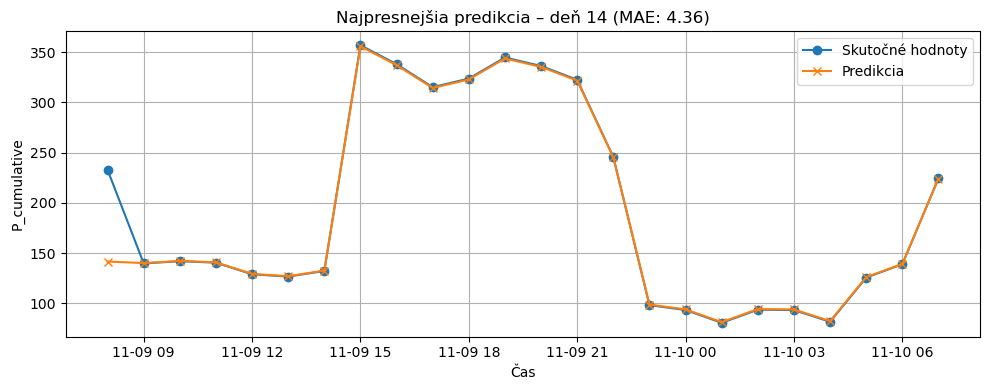


Predikcie pre všetky testovacie dni (najlepšia kombinácia):


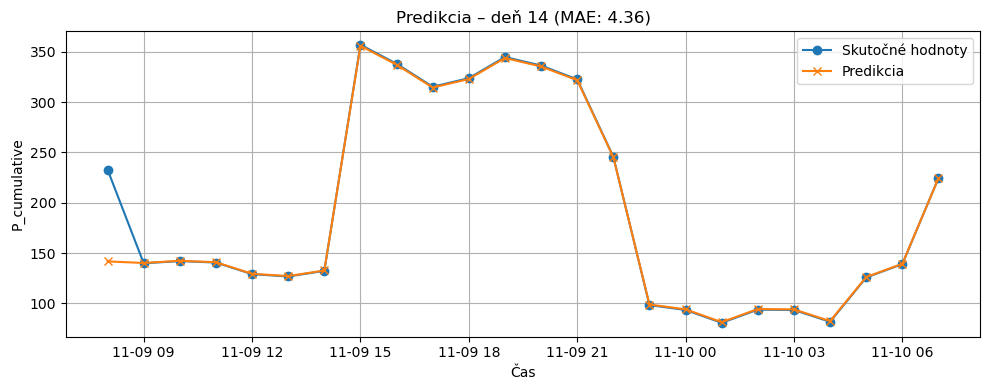

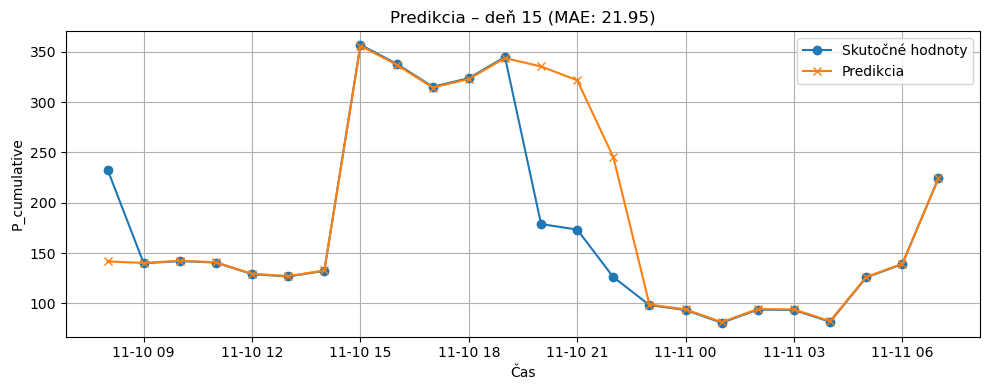

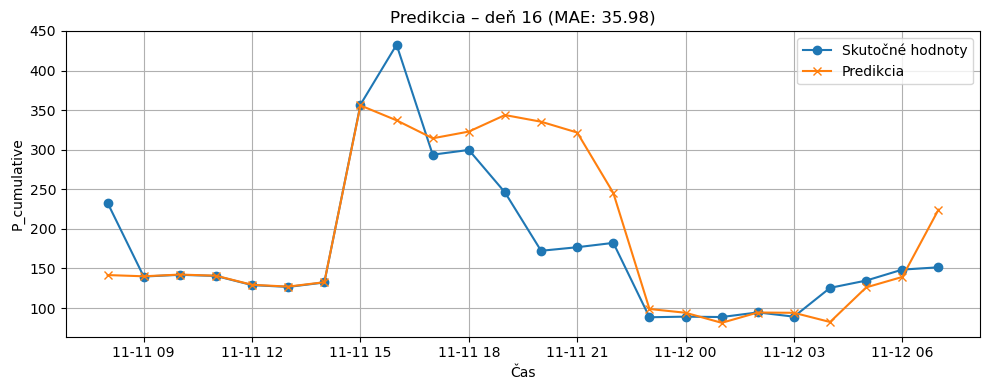

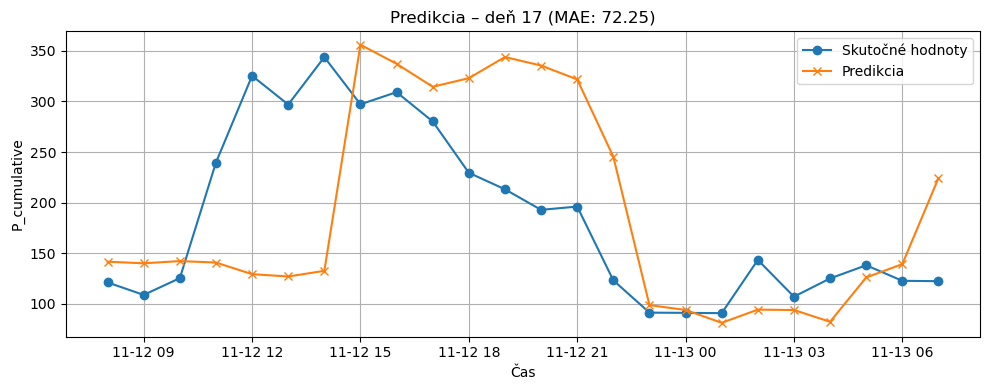

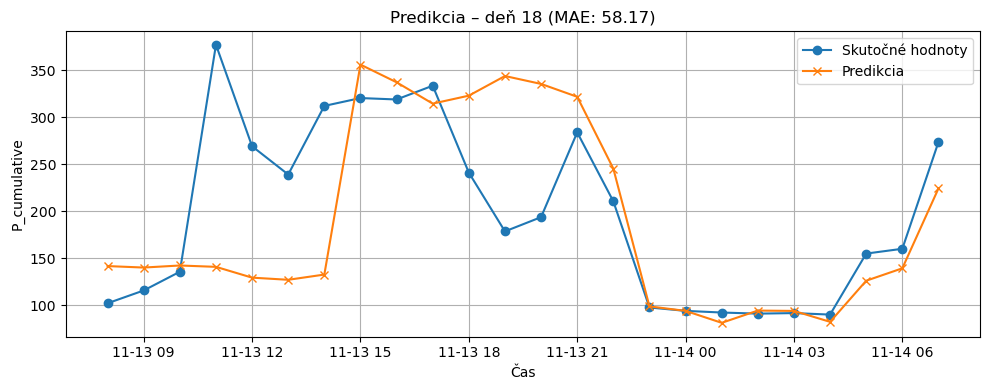

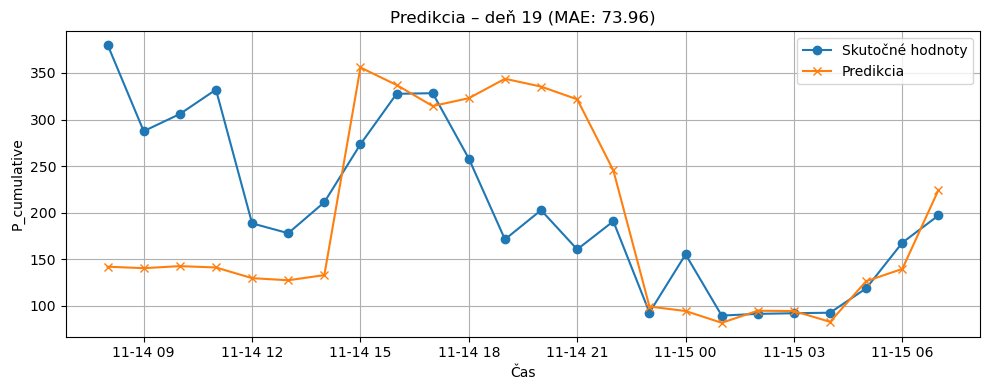

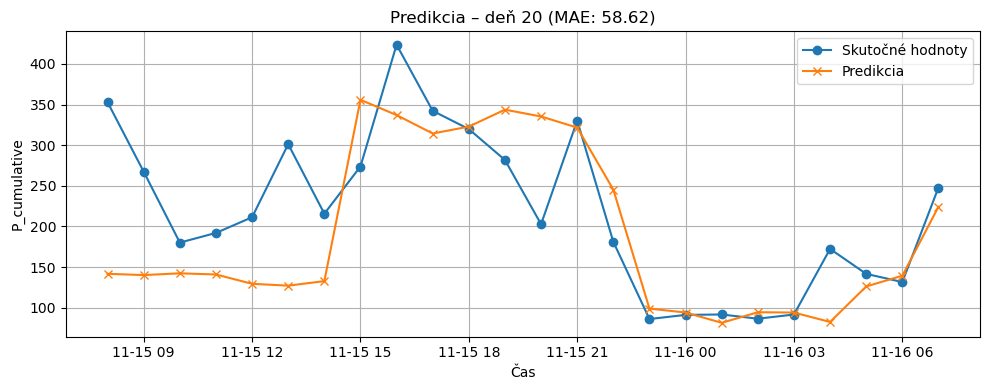

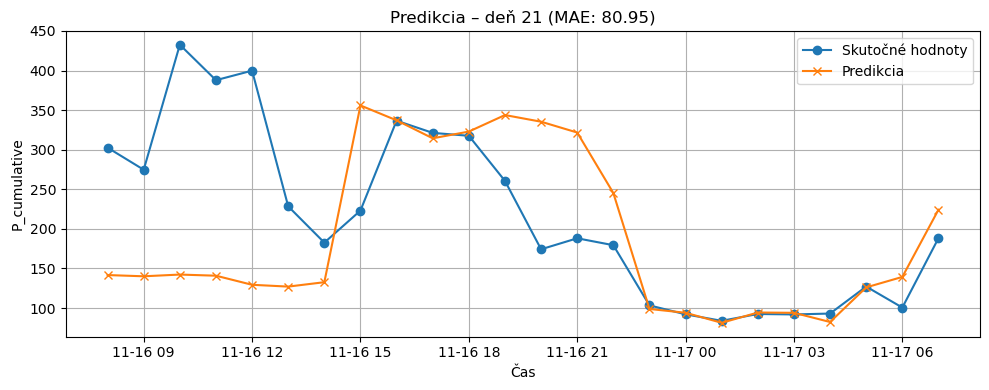

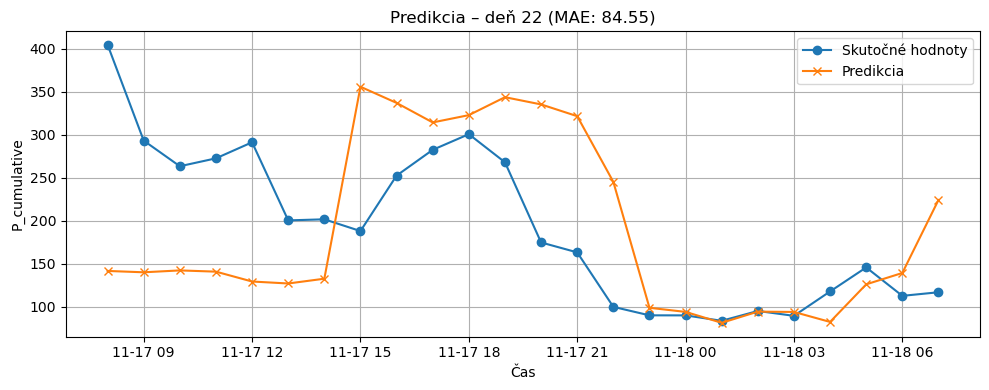

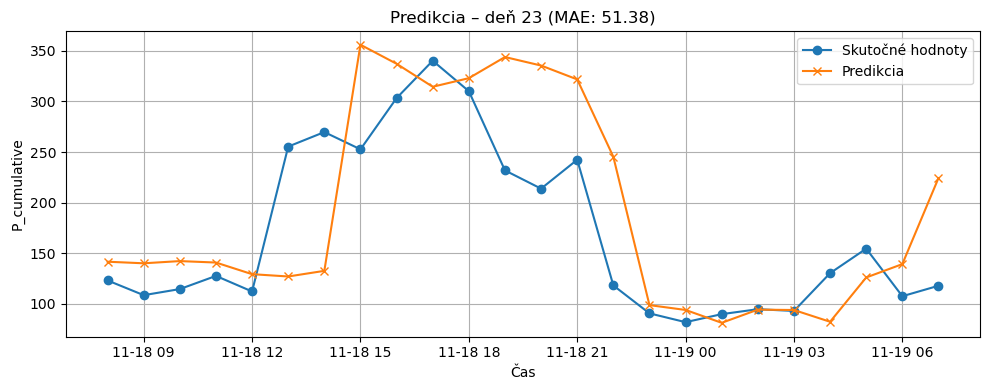

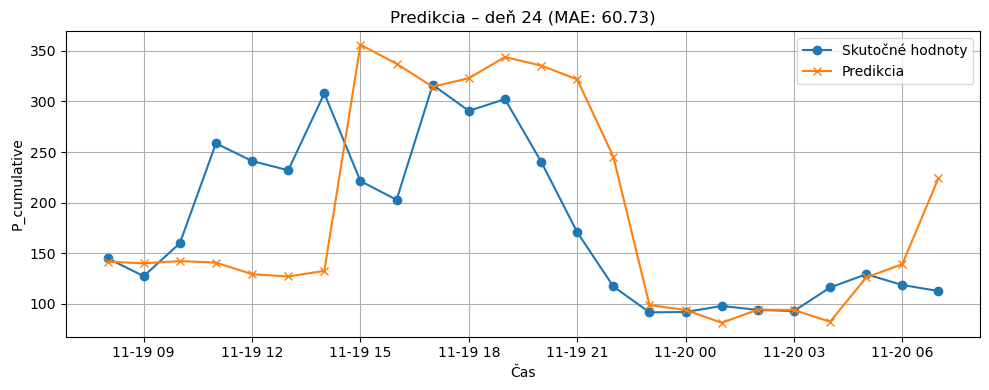

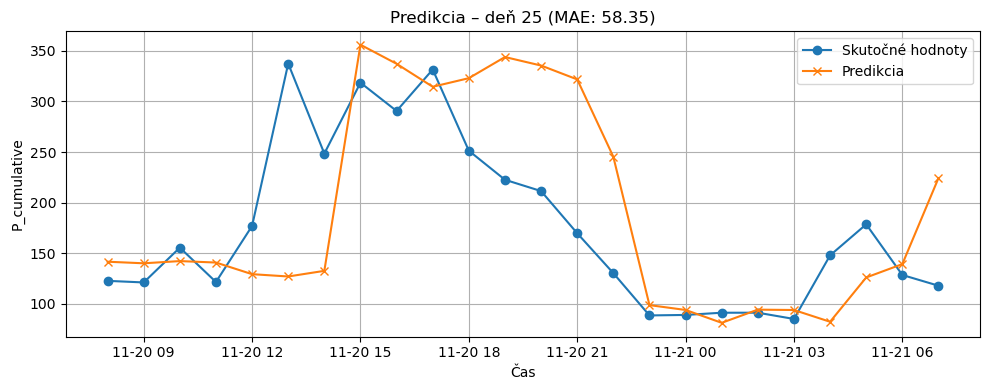

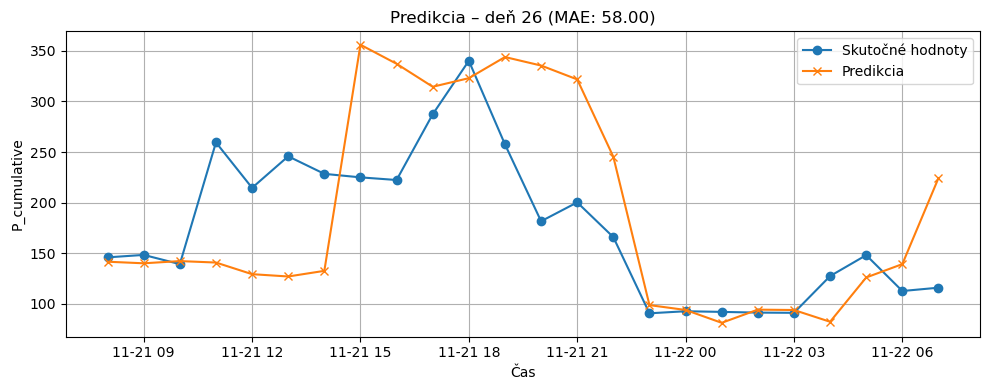

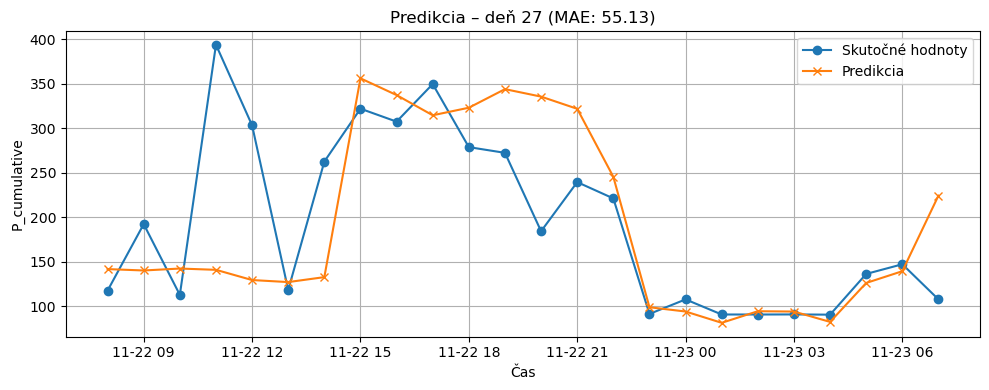

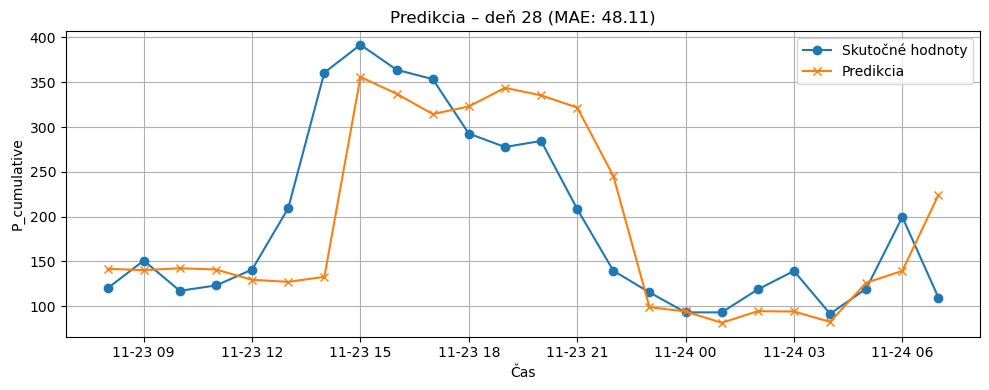

In [119]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from itertools import product

#Úprava dát – zabezpečenie hodinovej frekvencie a odstránenie prípadných chýbajúcich hodnôt
df2 = df2.sort_index().asfreq('H').dropna()

#Definovanie vstupných atribútov a cieľovej premennej
features = [col for col in df2.columns if col != 'P_cumulative'] #Všetky atribúty okrem 'P_cumulative'

target_col = 'P_cumulative' # cieľova premenna 'P_cumulative'

X_raw = df2[features]
y_raw = df2[[target_col]]

# Parametre dĺžky tréningového okna a testovania
train_days = 7 # počet dní na trénovanie
test_gap_days = 1  # medzera medzi tréningom a testovaním 
max_test_day = 28 # maximálny deň testovania

# Definovanie množiny parametrov pre GridSearch
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5]
}
# Uchovávanie výsledkov GridSearch
grid_results = []

# Vytvorenie pomocnych premennych ktore budu sluzit na zachytenie najlepsich globalnych vysledkov
global_best_mae = float('inf') # Najlepšie MAE je inicializované na nekonečno, každá reálna hodnota ho dokáže prekonať
global_best_pred = None #Uloženie predikcie modelu s najnižšou MAE
global_best_true = None #Reálne hodnoty pri najnižšej MAE
global_best_index = None #
global_best_day = None # Testovací deň, v ktorom bola dosiahnutá najnižšia MAE
global_best_train_range = "" # Tréningový interval (napr. "2-8") vedúci k najlepšej predikcii
global_best_params = {} # Najlepšia kombinácia hyperparametrov

# Vnorený cyklus pre všetky kombinácie hyperparametrov v GridSearch
for n_estimators, learning_rate, max_depth in product(param_grid['n_estimators'],
                                                       param_grid['learning_rate'],
                                                       param_grid['max_depth']):

    # Vytvorenie pomocnych premennych na sledovanie vysledkov pre konkretnu kombinaciu parametrov GridSearchu
    mae_all = []  # Zoznam MAE hodnôt pre túto kombináciu
    mape_all = [] # Zoznam MAPE hodnôt pre túto kombináciu
    best_mae = float('inf') # # Najnižšia MAE hodnota pre túto kombináciu, inicializovaná na nekonečno, pretože ju dokáže prekonať každá reálna hodnota
    best_train_range = "" # Tréningový interval s najlepším výsledkom
    # Posuvné okno pre výber tréningových dát zo 7 rôznych počiatočných dní
    #Posuvne okno pre vyber treningovych dat zo 7 roznych pociatocnych dni
    for train_start_day in range(1, 8):  # Posuvné okno – skúša trénovanie od každého dňa od 1 po 7
        train_start = train_start_day * 24  # Začiatok trénovacích dát (v hodinách)
        train_end = train_start + train_days * 24  # Koniec trénovacích dát (trvanie okna = počet dní * 24 hodín)
        target_start = train_end  # Začiatok cieľového intervalu – teda dňa, ktorý chceme predikovať
        target_end = target_start + 24  # Koniec cieľového intervalu – predikujeme presne jeden deň (24 hodín)

        # Poistka, aby sa nepoužilo viac dát, než máme k dispozícii
        if target_end > len(df2): # Ak koniec cieľového intervalu presahuje dostupné dáta
            continue # Preskoč danú iteráciu a pokračuj ďalšou
        #Normalizácia vstupov a cieľov pomocou MinMax škálovania, 
        scaler_X = MinMaxScaler() # Inicializácia škálovača pre vstupné atribúty – prevedie ich do rozsahu (0, 1)
        scaler_y = MinMaxScaler() # Inicializácia škálovača pre cieľové hodnoty – rovnako prevedie do rozsahu (0, 1)

        X_train = scaler_X.fit_transform(X_raw.iloc[train_start:train_end]) # Škálovanie vstupných atribútov pre trénovací interval
        y_train = scaler_y.fit_transform(y_raw.iloc[target_start:target_end])# Škálovanie cieľových hodnôt pre predikovaný deň
        X_train_flat = X_train.flatten().reshape(1, -1) # Zreťazenie všetkých vstupov do jedného 1D poľa a jeho tvarovanie na 2D – tvar (1, počet hodnôt)
        #Tréning modelu XGBoost s aktuálnymi hyperparametrami
        model = XGBRegressor(n_estimators=n_estimators,
                             learning_rate=learning_rate,
                             max_depth=max_depth)
        model.fit(X_train_flat, y_train.ravel())
         # # Posuvné testovanie, začína sa až po trénovacom období + medzere(gap), pokračuje až po max_test_day
        for test_day in range(train_start_day + train_days + test_gap_days, max_test_day + 1):
            x_start = (test_day - train_days) * 24
            x_end = test_day * 24
            y_start = test_day * 24
            y_end = y_start + 24

            #poistka
            if y_end > len(df2):# Ak testovacie dáta presahujú dostupné dáta, preskočí sa táto iterácia
                continue
            # Príprava testovacích dát, škálovanie a transformácia vstupov do požadovaného tvaru
            # cieľové hodnoty sa škálujú a následne invertujú na porovnanie s predikciou
            X_test = scaler_X.transform(X_raw.iloc[x_start:x_end]).flatten().reshape(1, -1)
            y_test = scaler_y.transform(y_raw.iloc[y_start:y_end])
            y_test_inv = scaler_y.inverse_transform(y_test).flatten()
            #flatten - zreťazí všetky časové údaje do jedného dlhého vektora.
            #reshape(1, -1) vytvorí jeden riadok vhodný pre model, ktorý tak spracuje celý priebeh ako jednu vzorku.

            y_pred = model.predict(X_test).reshape(-1, 1)
            y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()
            # Vyhodnotenie predikcie pomocou metrik MAE a MAPE
            mae = mean_absolute_error(y_test_inv, y_pred_inv)
            mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
            # Uloženie výsledkov
            mae_all.append(mae)
            mape_all.append(mape)
            # Aktualizácia najlepšieho výsledku pre danú kombináciu
            if mae < best_mae:
                best_mae = mae
                best_train_range = f"{train_start_day}-{train_start_day + train_days - 1}"
            # Globálna aktualizácia najlepšieho modelu (naprieč všetkými kombináciami)
            if mae < global_best_mae:
                global_best_mae = mae
                global_best_pred = y_pred_inv.copy()
                global_best_true = y_test_inv.copy()
                global_best_index = df2.index[y_start:y_end]
                global_best_day = test_day
                global_best_train_range = f"{train_start_day}-{train_start_day + train_days - 1}"
                global_best_params = {
                    'n_estimators': n_estimators,
                    'learning_rate': learning_rate,
                    'max_depth': max_depth
                }
    # Uloženie výsledkov pre aktuálnu kombináciu hyperparametrov
    grid_results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'avg_mae': np.mean(mae_all),
        'min_mae': np.min(mae_all),
        'max_mae': np.max(mae_all),
        'avg_mape': np.mean(mape_all),
        'min_mape': np.min(mape_all),
        'max_mape': np.max(mape_all),
        'best_train_range': best_train_range
    })

# Výpis výsledkov
df_grid = pd.DataFrame(grid_results) # Vytvorenie tabuľky zo zoznamu výsledkov pre všetky kombinácie parametrov
df_sorted = df_grid.sort_values(by='avg_mae') # Zoradenie výsledkov podľa priemernej MAE od najnižšej po najvyššiu

print("\nVýsledky GridSearch (tréning: 7 dní + gap, sliding window, testovanie na df2):")
print(df_sorted)

# Najlepšia konfigurácia
best = df_sorted.iloc[0]
print("\nNajlepšia kombinácia parametrov podľa priemernej MAE:")
print(f"n_estimators = {best['n_estimators']}")
print(f"learning_rate = {best['learning_rate']}")
print(f"max_depth = {best['max_depth']}")
print(f"Tréningový interval: {best['best_train_range']}")
print(f"MAE: priemer = {best['avg_mae']:.2f}, min = {best['min_mae']:.2f}, max = {best['max_mae']:.2f}")
print(f"MAPE: priemer = {best['avg_mape']*100:.2f}%, min = {best['min_mape']*100:.2f}%, max = {best['max_mape']*100:.2f}%")

# Najlepšia predikcia
print("\nNajpresnejšia predikcia (najnižšie MAE počas GridSearch):")
print(f"Testovací deň: {global_best_day}")
print(f"Tréningový interval: {global_best_train_range}")
print(f"Parametre: {global_best_params}")
print(f"MAE: {global_best_mae:.2f}")

# GRAF najlepšej predikcie
plt.figure(figsize=(10, 4))
plt.plot(global_best_index, global_best_true, label='Skutočné hodnoty', marker='o')
plt.plot(global_best_index, global_best_pred, label='Predikcia', marker='x')
plt.title(f"Najpresnejšia predikcia – deň {global_best_day} (MAE: {global_best_mae:.2f})")
plt.xlabel("Čas")
plt.ylabel("P_cumulative")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# GRAFY pre všetky testovacie dni – vizualizácia predikcií pomocou najlepšej nájdenej kombinácie parametrov
print("\nPredikcie pre všetky testovacie dni (najlepšia kombinácia):")

train_start_best = int(global_best_train_range.split('-')[0]) * 24  # Začiatok trénovacieho intervalu (v hodinách) podľa najlepšej konfigurácie
train_end_best = train_start_best + train_days * 24  # Koniec trénovacieho intervalu (v hodinách)

scaler_X = MinMaxScaler()  # Inicializácia škálovača pre vstupné atribúty
scaler_y = MinMaxScaler()  # Inicializácia škálovača pre cieľové hodnoty

X_train = scaler_X.fit_transform(X_raw.iloc[train_start_best:train_end_best])  # Škálovanie vstupov pre najlepší tréningový interval
y_train = scaler_y.fit_transform(y_raw.iloc[train_end_best:train_end_best + 24])  # Škálovanie cieľa (nasledujúci deň po tréningu)
X_train_flat = X_train.flatten().reshape(1, -1)  # Prevod na tvar (1, počet hodnôt), jedna vzorka reprezentujúca celé trénovacie okno

best_model = XGBRegressor(**global_best_params)  # Opätovné vytvorenie modelu s najlepšou kombináciou hyperparametrov
best_model.fit(X_train_flat, y_train.ravel())  # Trénovanie modelu na najlepšom intervale

# Testovanie na všetky testovacie dni po danom tréningovom období
for test_day in range(train_start_best // 24 + train_days + test_gap_days, max_test_day + 1):
    x_start = (test_day - train_days) * 24  # Začiatok testovacieho intervalu (v hodinách)
    x_end = test_day * 24  # Koniec testovacieho intervalu
    y_start = test_day * 24  # Začiatok cieľového intervalu (deň, ktorý predikujeme)
    y_end = y_start + 24  # Koniec cieľového intervalu

    if y_end > len(df2):  # Poistka – ak presahuje dostupné dáta, iterácia sa preskočí
        continue

    X_test = scaler_X.transform(X_raw.iloc[x_start:x_end]).flatten().reshape(1, -1)  # Príprava testovacích vstupov (škálovanie + zreťazenie)
    y_test = scaler_y.transform(y_raw.iloc[y_start:y_end])  # Škálovanie cieľových hodnôt
    y_test_inv = scaler_y.inverse_transform(y_test).flatten()  # Inverzia cieľa pre porovnanie v pôvodnej mierke

    y_pred = best_model.predict(X_test).reshape(-1, 1)  # Predikcia pomocou modelu
    y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()  # Inverzia predikcie na pôvodné jednotky

    mae = mean_absolute_error(y_test_inv, y_pred_inv)  # Výpočet MAE pre tento deň

    test_index = df2.index[y_start:y_end]  # Časový index pre vizualizáciu

    # Vykreslenie grafu porovnania skutočných a predikovaných hodnôt
    plt.figure(figsize=(10, 4))
    plt.plot(test_index, y_test_inv, label='Skutočné hodnoty', marker='o')
    plt.plot(test_index, y_pred_inv, label='Predikcia', marker='x')
    plt.title(f"Predikcia – deň {test_day} (MAE: {mae:.2f})")
    plt.xlabel("Čas")
    plt.ylabel("P_cumulative")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**14-dňový tréningový interval**


Výsledky GridSearch (tréning: 14 dní + gap, sliding window, testovanie na df2):
   n_estimators  learning_rate  max_depth    avg_mae    min_mae    max_mae  \
2           100           0.05          3  53.875223  19.863674  83.247242   
3           100           0.05          5  53.875223  19.863674  83.247242   
6           200           0.05          3  54.826162  19.468782  85.782422   
7           200           0.05          5  54.826162  19.468782  85.782422   
4           200           0.01          3  55.801563  29.847731  81.124081   
5           200           0.01          5  55.801563  29.847731  81.124081   
0           100           0.01          3  62.023543  37.951941  84.186286   
1           100           0.01          5  62.023543  37.951941  84.186286   

   avg_mape  min_mape  max_mape best_train_range  
2  0.294917  0.105712  0.553459             1-14  
3  0.294917  0.105712  0.553459             1-14  
6  0.294962  0.100271  0.565035             1-14  
7  0.294962 

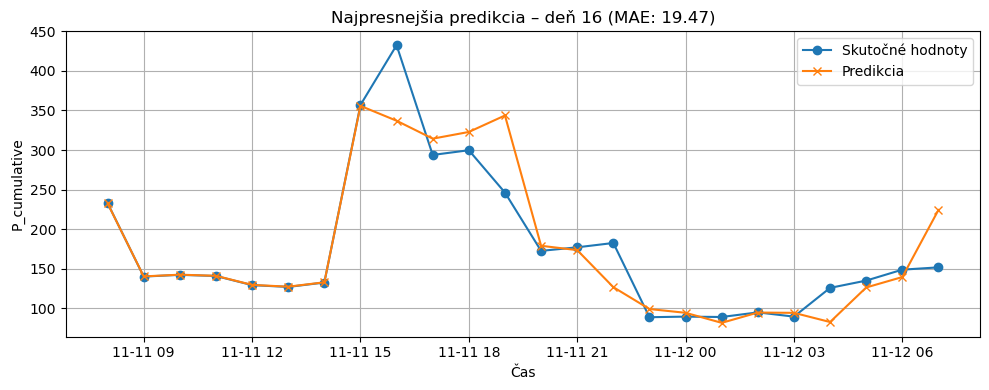


Predikcie pre všetky testovacie dni (najlepšia kombinácia):


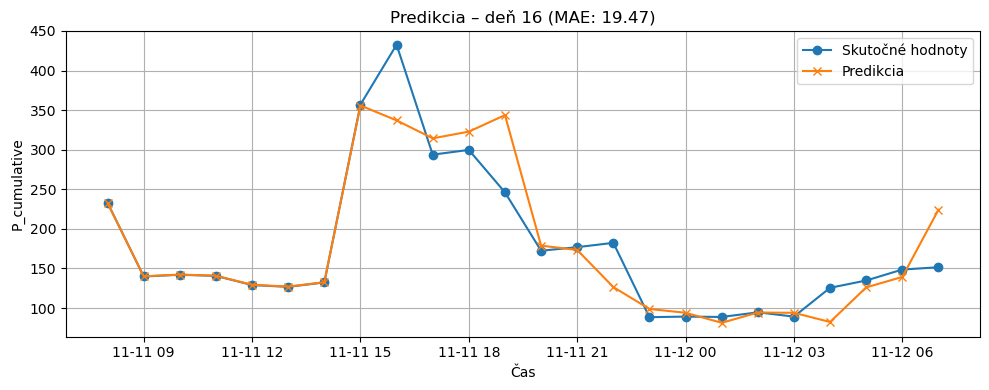

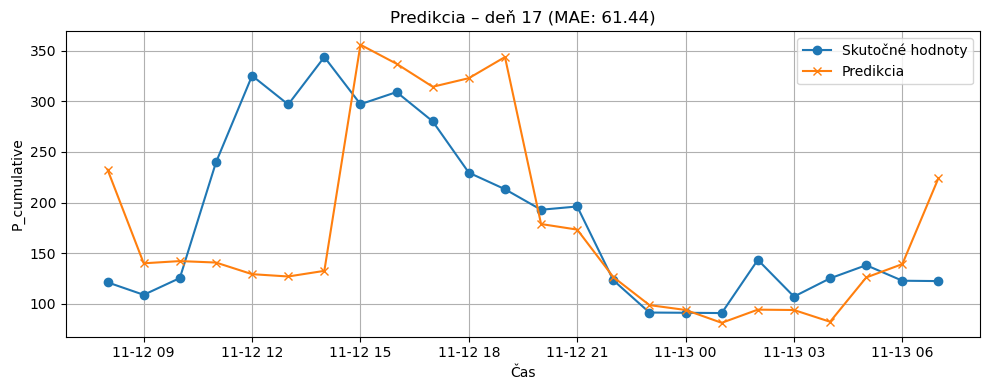

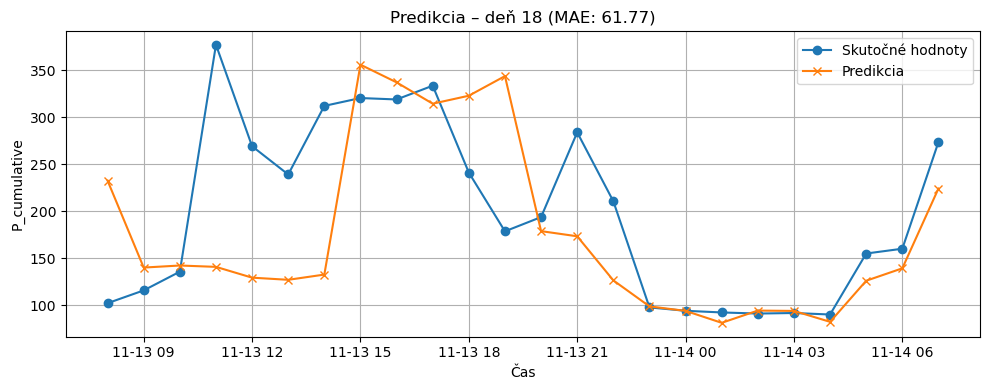

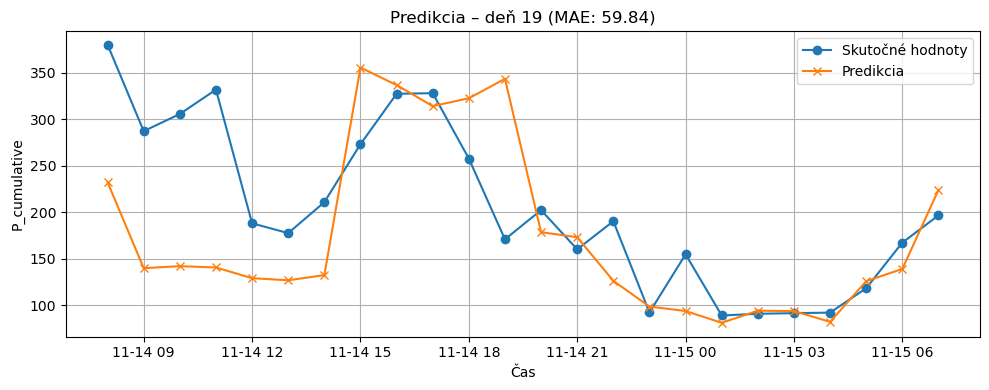

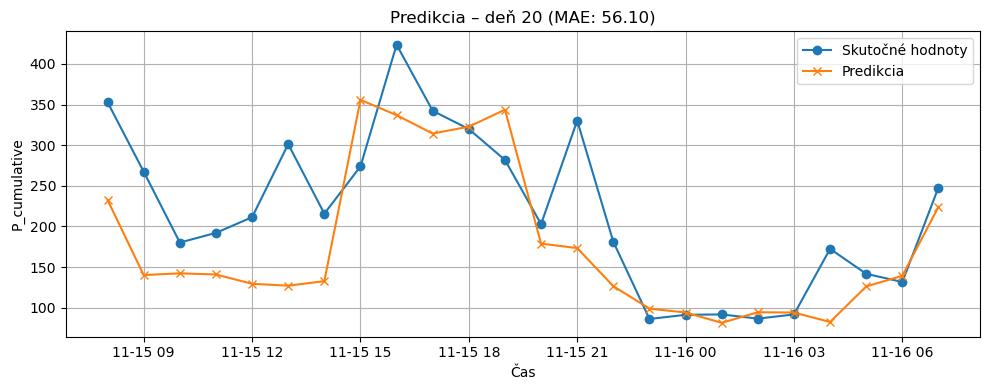

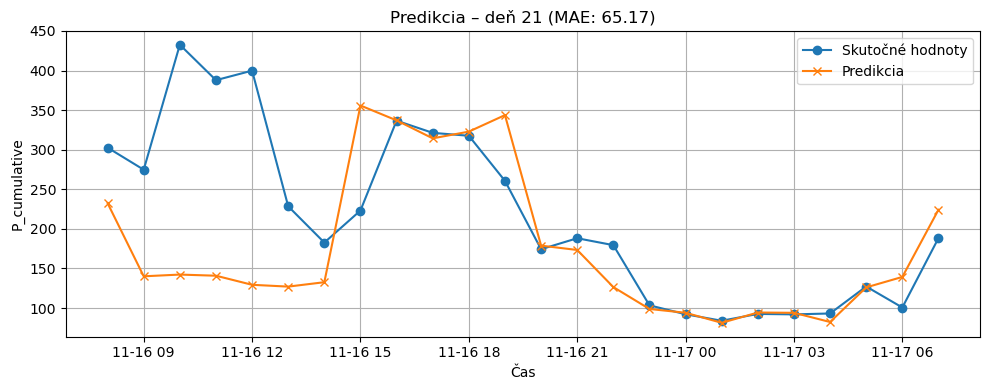

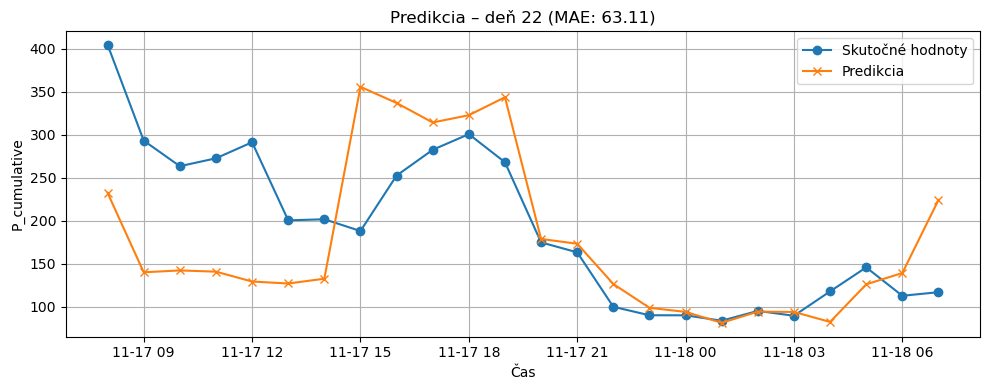

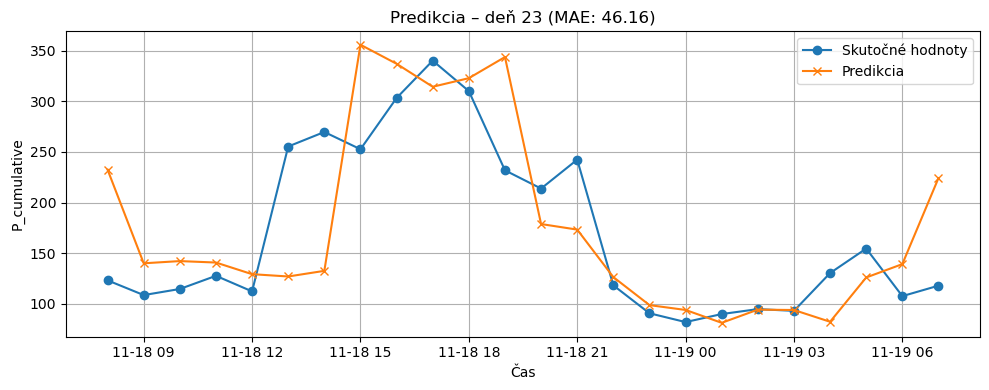

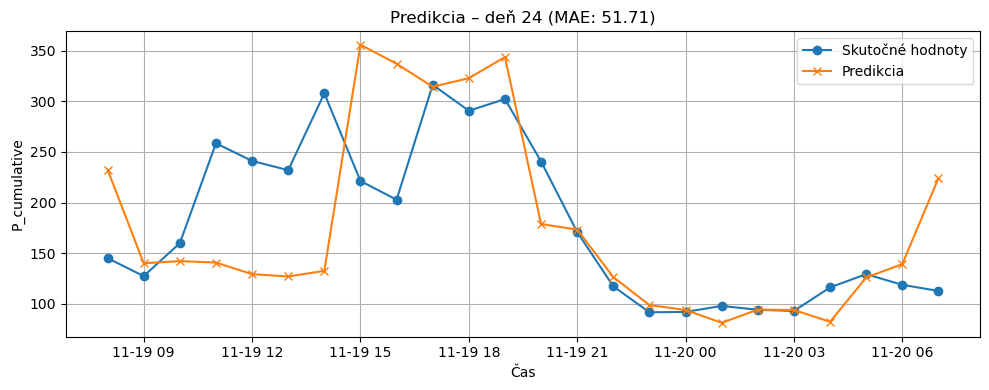

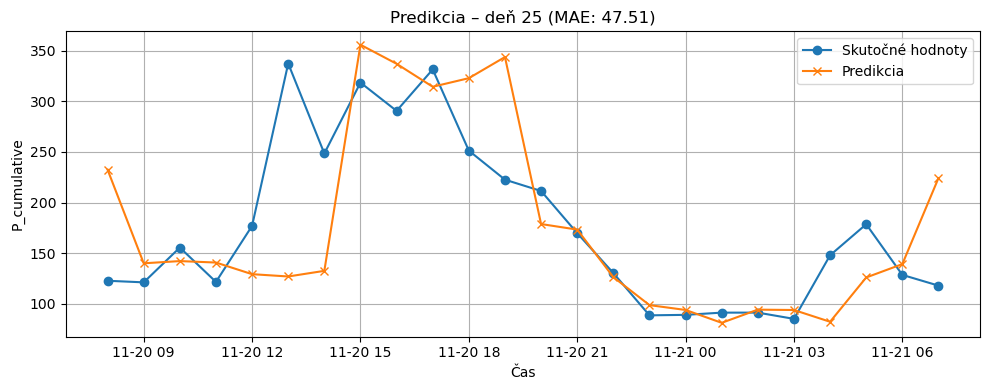

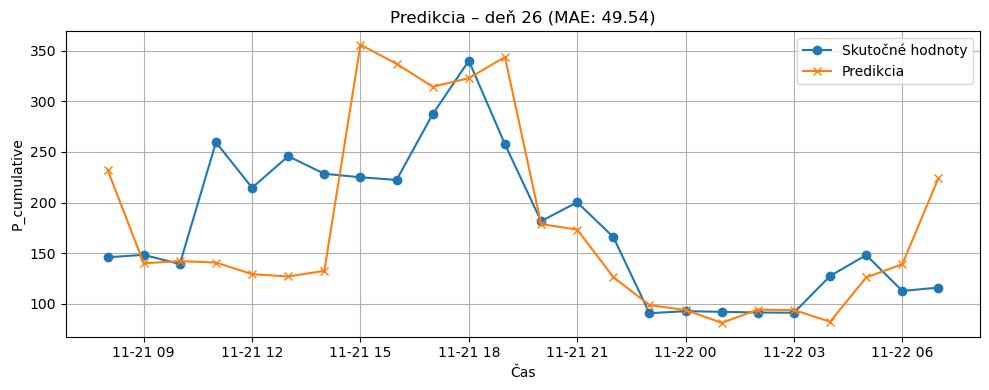

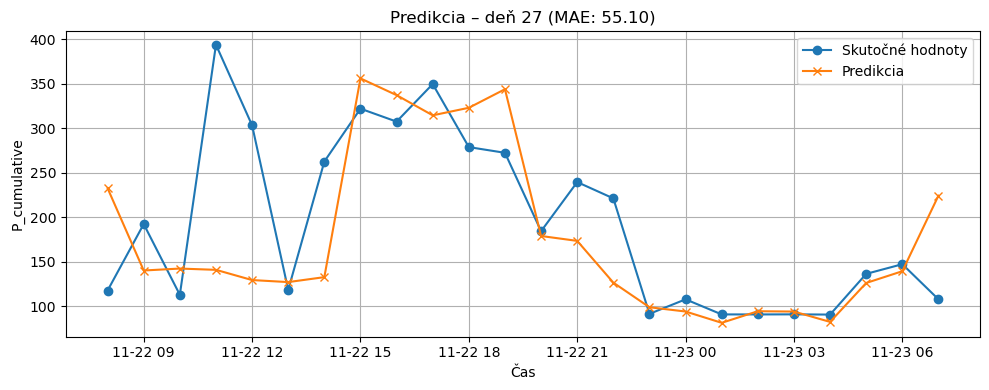

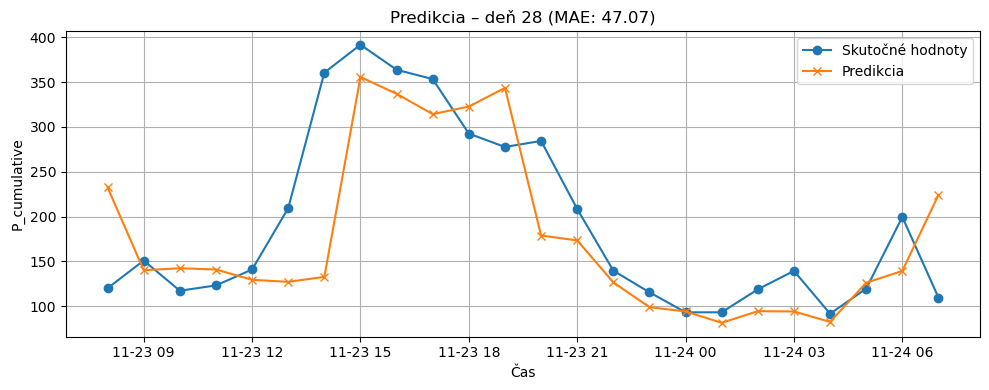

In [40]:
# Import knižníc
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # Potlačenie varovaní
from itertools import product  # Na generovanie kombinácií parametrov

# Úprava dát: zoradenie podľa času, nastavenie frekvencie a odstránenie NaN hodnôt
df2 = df2.sort_index().asfreq('H').dropna()

# Rozdelenie atribútov a cieľovej premennej
features = [col for col in df2.columns if col != 'P_cumulative']
target_col = 'P_cumulative'

X_raw = df2[features]            # Vstupné atribúty
y_raw = df2[[target_col]]        # Výstupná premenná

# Parametre pre trénovanie a testovanie
train_days = 14                 # Dĺžka trénovacieho okna
test_gap_days = 1               # Medzera medzi tréningom a testom
max_test_day = 28              # Posledný deň testovania

# Definovanie GridSearch parametrov
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5]
}

grid_results = []

# Premenné na sledovanie najlepšej globálnej predikcie
global_best_mae = float('inf')
global_best_pred = None
global_best_true = None
global_best_index = None
global_best_day = None
global_best_train_range = ""
global_best_params = {}

# GRIDSEARCH – iterácia cez všetky kombinácie parametrov
for n_estimators, learning_rate, max_depth in product(param_grid['n_estimators'],
                                                       param_grid['learning_rate'],
                                                       param_grid['max_depth']):

    mae_all = []
    mape_all = []
    best_mae = float('inf')
    best_train_range = ""

    for train_start_day in range(1, 8):  # Sliding window – posúvanie začiatku trénovania
        train_start = train_start_day * 24
        train_end = train_start + train_days * 24
        target_start = train_end
        target_end = target_start + 24

        if target_end > len(df2):
            continue

        # Škálovanie dát
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        X_train = scaler_X.fit_transform(X_raw.iloc[train_start:train_end])
        y_train = scaler_y.fit_transform(y_raw.iloc[target_start:target_end])
        X_train_flat = X_train.flatten().reshape(1, -1)

        # Tréning modelu
        model = XGBRegressor(n_estimators=n_estimators,
                             learning_rate=learning_rate,
                             max_depth=max_depth)
        model.fit(X_train_flat, y_train.ravel())

        # Testovanie s 1-dňovým gapom po tréningu
        for test_day in range(train_start_day + train_days + test_gap_days, max_test_day + 1):
            x_start = (test_day - train_days) * 24
            x_end = test_day * 24
            y_start = test_day * 24
            y_end = y_start + 24

            if y_end > len(df2):
                continue

            X_test = scaler_X.transform(X_raw.iloc[x_start:x_end]).flatten().reshape(1, -1)
            y_test = scaler_y.transform(y_raw.iloc[y_start:y_end])
            y_test_inv = scaler_y.inverse_transform(y_test).flatten()

            y_pred = model.predict(X_test).reshape(-1, 1)
            y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

            mae = mean_absolute_error(y_test_inv, y_pred_inv)
            mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

            mae_all.append(mae)
            mape_all.append(mape)

            # Sledovanie najlepšej predikcie pre túto konfiguráciu a aj globálne
            if mae < best_mae:
                best_mae = mae
                best_train_range = f"{train_start_day}-{train_start_day + train_days - 1}"

            if mae < global_best_mae:
                global_best_mae = mae
                global_best_pred = y_pred_inv.copy()
                global_best_true = y_test_inv.copy()
                global_best_index = df2.index[y_start:y_end]
                global_best_day = test_day
                global_best_train_range = f"{train_start_day}-{train_start_day + train_days - 1}"
                global_best_params = {
                    'n_estimators': n_estimators,
                    'learning_rate': learning_rate,
                    'max_depth': max_depth
                }

    # Uloženie výsledkov pre danú kombináciu
    grid_results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'avg_mae': np.mean(mae_all),
        'min_mae': np.min(mae_all),
        'max_mae': np.max(mae_all),
        'avg_mape': np.mean(mape_all),
        'min_mape': np.min(mape_all),
        'max_mape': np.max(mape_all),
        'best_train_range': best_train_range
    })

# Vytvorenie a zoradenie výsledkov
df_grid = pd.DataFrame(grid_results)
df_sorted = df_grid.sort_values(by='avg_mae')

# Výpis najlepšej kombinácie
print("\nVýsledky GridSearch (tréning: 14 dní + gap, sliding window, testovanie na df2):")
print(df_sorted)

best = df_sorted.iloc[0]
print("\nNajlepšia kombinácia parametrov podľa priemernej MAE:")
print(f"n_estimators = {best['n_estimators']}")
print(f"learning_rate = {best['learning_rate']}")
print(f"max_depth = {best['max_depth']}")
print(f"Tréningový interval: {best['best_train_range']}")
print(f"MAE: priemer = {best['avg_mae']:.2f}, min = {best['min_mae']:.2f}, max = {best['max_mae']:.2f}")
print(f"MAPE: priemer = {best['avg_mape']*100:.2f}%, min = {best['min_mape']*100:.2f}%, max = {best['max_mape']*100:.2f}%")

# Najlepšia predikcia globálne
print("\nNajpresnejšia predikcia (najnižšie MAE počas GridSearch):")
print(f"Testovací deň: {global_best_day}")
print(f"Tréningový interval: {global_best_train_range}")
print(f"Parametre: {global_best_params}")
print(f"MAE: {global_best_mae:.2f}")

# Vizualizácia najpresnejšej predikcie
plt.figure(figsize=(10, 4))
plt.plot(global_best_index, global_best_true, label='Skutočné hodnoty', marker='o')
plt.plot(global_best_index, global_best_pred, label='Predikcia', marker='x')
plt.title(f"Najpresnejšia predikcia – deň {global_best_day} (MAE: {global_best_mae:.2f})")
plt.xlabel("Čas")
plt.ylabel("P_cumulative")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Vizualizácia všetkých dní pre najlepšiu kombináciu
print("\nPredikcie pre všetky testovacie dni (najlepšia kombinácia):")
train_start_best = int(global_best_train_range.split('-')[0]) * 24
train_end_best = train_start_best + train_days * 24

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_raw.iloc[train_start_best:train_end_best])
y_train = scaler_y.fit_transform(y_raw.iloc[train_end_best:train_end_best + 24])
X_train_flat = X_train.flatten().reshape(1, -1)

best_model = XGBRegressor(**global_best_params)
best_model.fit(X_train_flat, y_train.ravel())

for test_day in range(train_start_best // 24 + train_days + test_gap_days, max_test_day + 1):
    x_start = (test_day - train_days) * 24
    x_end = test_day * 24
    y_start = test_day * 24
    y_end = y_start + 24

    if y_end > len(df2):
        continue

    X_test = scaler_X.transform(X_raw.iloc[x_start:x_end]).flatten().reshape(1, -1)
    y_test = scaler_y.transform(y_raw.iloc[y_start:y_end])
    y_test_inv = scaler_y.inverse_transform(y_test).flatten()

    y_pred = best_model.predict(X_test).reshape(-1, 1)
    y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

    mae = mean_absolute_error(y_test_inv, y_pred_inv)

    test_index = df2.index[y_start:y_end]
    plt.figure(figsize=(10, 4))
    plt.plot(test_index, y_test_inv, label='Skutočné hodnoty', marker='o')
    plt.plot(test_index, y_pred_inv, label='Predikcia', marker='x')
    plt.title(f"Predikcia – deň {test_day} (MAE: {mae:.2f})")
    plt.xlabel("Čas")
    plt.ylabel("P_cumulative")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**21-dňový tréningový interval**


Výsledky GridSearch (tréning: 21 dní + gap, sliding window, testovanie na df2):
   n_estimators  learning_rate  max_depth    avg_mae    min_mae    max_mae  \
2           100           0.05          3  44.415934  20.874348  76.327273   
3           100           0.05          5  44.415934  20.874348  76.327273   
6           200           0.05          3  44.774577  20.682052  78.799663   
7           200           0.05          5  44.774577  20.682052  78.799663   
4           200           0.01          3  48.895425  25.699451  74.344259   
5           200           0.01          5  48.895425  25.699451  74.344259   
0           100           0.01          3  57.238243  36.220870  77.376316   
1           100           0.01          5  57.238243  36.220870  77.376316   

   avg_mape  min_mape  max_mape best_train_range  
2  0.245712  0.113887  0.445694             3-23  
3  0.245712  0.113887  0.445694             3-23  
6  0.246611  0.105884  0.465670             3-23  
7  0.246611 

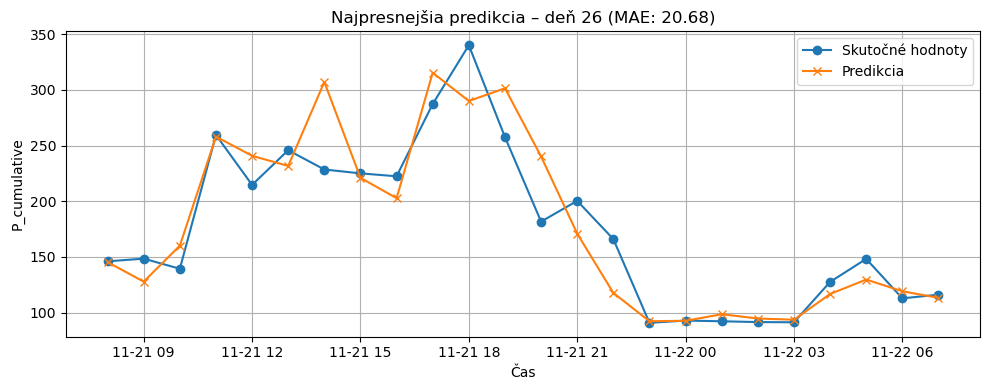


Predikcie pre všetky testovacie dni (najlepšia kombinácia):


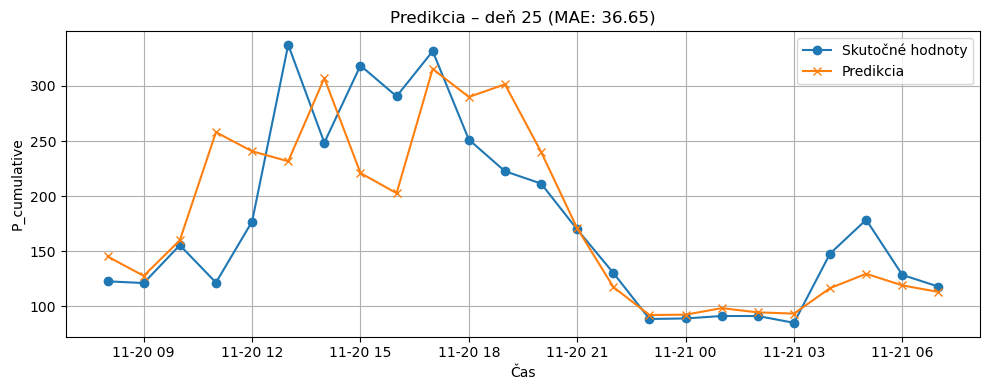

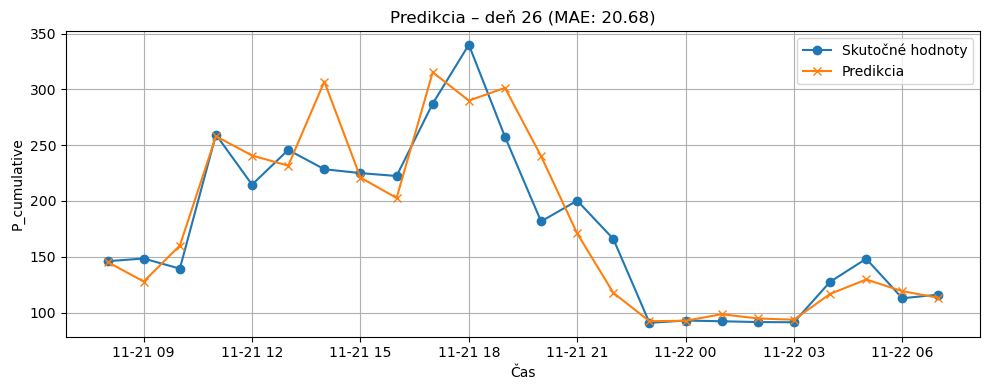

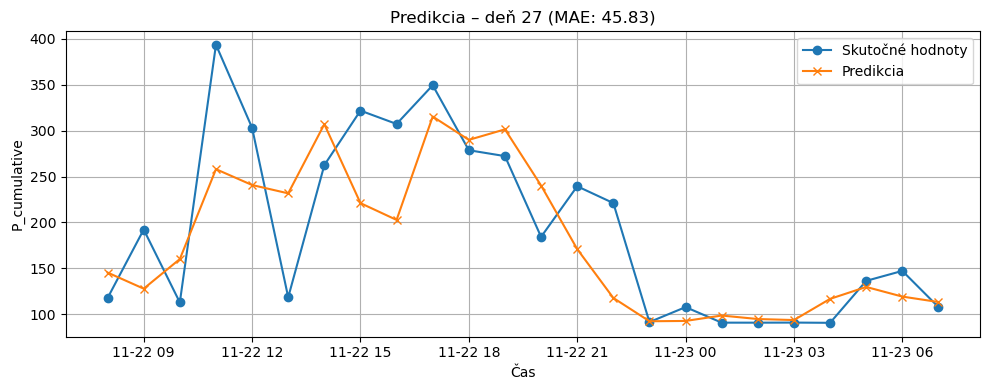

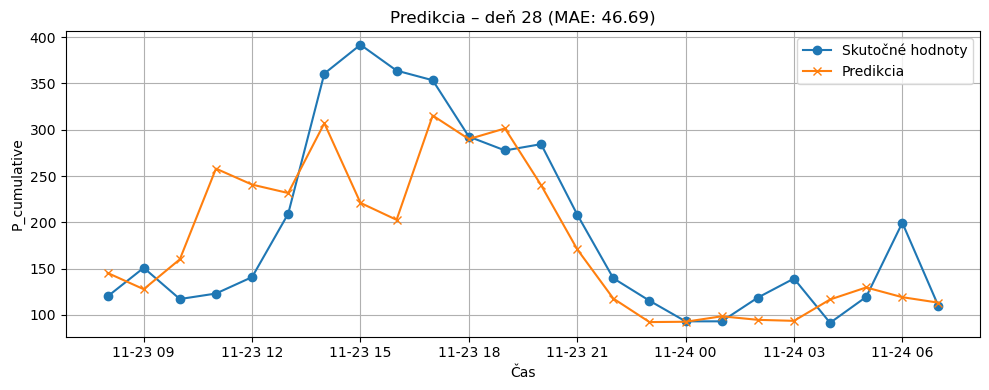

In [115]:
# Import potrebných knižníc
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # Potlačenie varovaní
from itertools import product  # Na kombinovanie parametrov v GridSearch

# Úprava dát: zoradenie podľa času, nastavenie hodinovej frekvencie, odstránenie NaN hodnôt
df2 = df2.sort_index().asfreq('H').dropna()

# Rozdelenie na vstupné a výstupné premenné
features = [col for col in df2.columns if col != 'P_cumulative']
target_col = 'P_cumulative'

X_raw = df2[features]  # Všetky vstupné atribúty
y_raw = df2[[target_col]]  # Cieľová premenná

# Parametre pre trénovanie a testovanie
train_days = 21               # Dĺžka trénovacieho okna
test_gap_days = 1             # Medzera medzi trénovaním a testovaním
max_test_day = 28            # Posledný deň testovania (v dňoch)

# Definovanie GridSearch parametrov
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5]
}

grid_results = []

# Premenné pre najlepší výsledok (globálne naprieč všetkými testami)
global_best_mae = float('inf')
global_best_pred = None
global_best_true = None
global_best_index = None
global_best_day = None
global_best_train_range = ""
global_best_params = {}

# GridSearch cez všetky kombinácie hyperparametrov
for n_estimators, learning_rate, max_depth in product(param_grid['n_estimators'],
                                                       param_grid['learning_rate'],
                                                       param_grid['max_depth']):

    mae_all = []
    mape_all = []
    best_mae = float('inf')
    best_train_range = ""

    # Sliding window - rôzne posuny začiatku tréningu
    for train_start_day in range(1, 8):
        train_start = train_start_day * 24
        train_end = train_start + train_days * 24
        target_start = train_end
        target_end = target_start + 24

        if target_end > len(df2):
            continue

        # Škálovanie dát
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        X_train = scaler_X.fit_transform(X_raw.iloc[train_start:train_end])
        y_train = scaler_y.fit_transform(y_raw.iloc[target_start:target_end])
        X_train_flat = X_train.flatten().reshape(1, -1)

        # Tréning modelu
        model = XGBRegressor(n_estimators=n_estimators,
                             learning_rate=learning_rate,
                             max_depth=max_depth)
        model.fit(X_train_flat, y_train.ravel())

        # Testovanie na viacerých dňoch
        for test_day in range(train_start_day + train_days + test_gap_days, max_test_day + 1):
            x_start = (test_day - train_days) * 24
            x_end = test_day * 24
            y_start = test_day * 24
            y_end = y_start + 24

            if y_end > len(df2):
                continue

            X_test = scaler_X.transform(X_raw.iloc[x_start:x_end]).flatten().reshape(1, -1)
            y_test = scaler_y.transform(y_raw.iloc[y_start:y_end])
            y_test_inv = scaler_y.inverse_transform(y_test).flatten()

            y_pred = model.predict(X_test).reshape(-1, 1)
            y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

            mae = mean_absolute_error(y_test_inv, y_pred_inv)
            mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

            mae_all.append(mae)
            mape_all.append(mape)

            # Lokálny aj globálny výber najlepšej predikcie
            if mae < best_mae:
                best_mae = mae
                best_train_range = f"{train_start_day}-{train_start_day + train_days - 1}"

            if mae < global_best_mae:
                global_best_mae = mae
                global_best_pred = y_pred_inv.copy()
                global_best_true = y_test_inv.copy()
                global_best_index = df2.index[y_start:y_end]
                global_best_day = test_day
                global_best_train_range = f"{train_start_day}-{train_start_day + train_days - 1}"
                global_best_params = {
                    'n_estimators': n_estimators,
                    'learning_rate': learning_rate,
                    'max_depth': max_depth
                }

    # Uloženie výsledkov pre danú kombináciu
    grid_results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'avg_mae': np.mean(mae_all),
        'min_mae': np.min(mae_all),
        'max_mae': np.max(mae_all),
        'avg_mape': np.mean(mape_all),
        'min_mape': np.min(mape_all),
        'max_mape': np.max(mape_all),
        'best_train_range': best_train_range
    })

# Zobrazenie výsledkov GridSearchu
df_grid = pd.DataFrame(grid_results)
df_sorted = df_grid.sort_values(by='avg_mae')

print("\nVýsledky GridSearch (tréning: 21 dní + gap, sliding window, testovanie na df2):")
print(df_sorted)

# Výpis najlepšej kombinácie
best = df_sorted.iloc[0]
print("\nNajlepšia kombinácia parametrov podľa priemernej MAE:")
print(f"n_estimators = {best['n_estimators']}")
print(f"learning_rate = {best['learning_rate']}")
print(f"max_depth = {best['max_depth']}")
print(f"Tréningový interval: {best['best_train_range']}")
print(f"MAE: priemer = {best['avg_mae']:.2f}, min = {best['min_mae']:.2f}, max = {best['max_mae']:.2f}")
print(f"MAPE: priemer = {best['avg_mape']*100:.2f}%, min = {best['min_mape']*100:.2f}%, max = {best['max_mape']*100:.2f}%")

# Výpis najpresnejšej predikcie (globálne najnižšie MAE)
print("\nNajpresnejšia predikcia (najnižšie MAE počas GridSearch):")
print(f"Testovací deň: {global_best_day}")
print(f"Tréningový interval: {global_best_train_range}")
print(f"Parametre: {global_best_params}")
print(f"MAE: {global_best_mae:.2f}")

# Vizualizácia najpresnejšej predikcie
plt.figure(figsize=(10, 4))
plt.plot(global_best_index, global_best_true, label='Skutočné hodnoty', marker='o')
plt.plot(global_best_index, global_best_pred, label='Predikcia', marker='x')
plt.title(f"Najpresnejšia predikcia – deň {global_best_day} (MAE: {global_best_mae:.2f})")
plt.xlabel("Čas")
plt.ylabel("P_cumulative")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Opätovný tréning najlepšieho modelu pre kompletnú vizualizáciu
print("\nPredikcie pre všetky testovacie dni (najlepšia kombinácia):")
train_start_best = int(global_best_train_range.split('-')[0]) * 24
train_end_best = train_start_best + train_days * 24

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_raw.iloc[train_start_best:train_end_best])
y_train = scaler_y.fit_transform(y_raw.iloc[train_end_best:train_end_best + 24])
X_train_flat = X_train.flatten().reshape(1, -1)

best_model = XGBRegressor(**global_best_params)
best_model.fit(X_train_flat, y_train.ravel())

for test_day in range(train_start_best // 24 + train_days + test_gap_days, max_test_day + 1):
    x_start = (test_day - train_days) * 24
    x_end = test_day * 24
    y_start = test_day * 24
    y_end = y_start + 24

    if y_end > len(df2):
        continue

    X_test = scaler_X.transform(X_raw.iloc[x_start:x_end]).flatten().reshape(1, -1)
    y_test = scaler_y.transform(y_raw.iloc[y_start:y_end])
    y_test_inv = scaler_y.inverse_transform(y_test).flatten()

    y_pred = best_model.predict(X_test).reshape(-1, 1)
    y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

    mae = mean_absolute_error(y_test_inv, y_pred_inv)

    test_index = df2.index[y_start:y_end]
    plt.figure(figsize=(10, 4))
    plt.plot(test_index, y_test_inv, label='Skutočné hodnoty', marker='o')
    plt.plot(test_index, y_pred_inv, label='Predikcia', marker='x')
    plt.title(f"Predikcia – deň {test_day} (MAE: {mae:.2f})")
    plt.xlabel("Čas")
    plt.ylabel("P_cumulative")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Testovanie na inej domácnosti

- Model bol trénovaný na údajoch z jednej domácnosti (dom) a testovaný na údajoch z inej domácnosti (byt)
- Prístup posuvného okna
- 7, 14 alebo 21-dňový iteračný cyklus
- Optimalizácia parametrov pomocou GridSearch


### 7-dňový cyklus


Výsledky GridSearch (zoradené podľa priemerného MAE):
    n_estimators  learning_rate  max_depth  train_start_day     avg_mae  \
41           200           0.01          5                7  129.431740   
34           200           0.01          3                7  129.431740   
4            100           0.01          3                5  129.780450   
11           100           0.01          5                5  129.780450   
2            100           0.01          3                3  129.872553   
9            100           0.01          5                3  129.872553   
6            100           0.01          3                7  130.040343   
13           100           0.01          5                7  130.040343   
32           200           0.01          3                5  132.670285   
39           200           0.01          5                5  132.670285   
5            100           0.01          3                6  133.639938   
12           100           0.01          5   

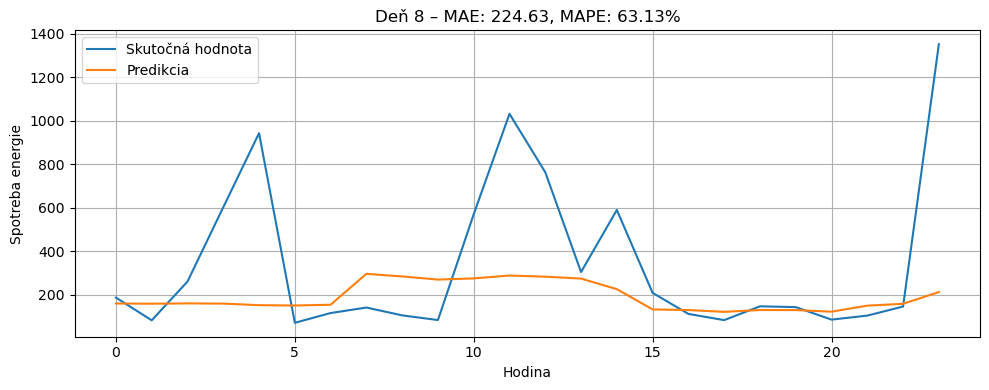

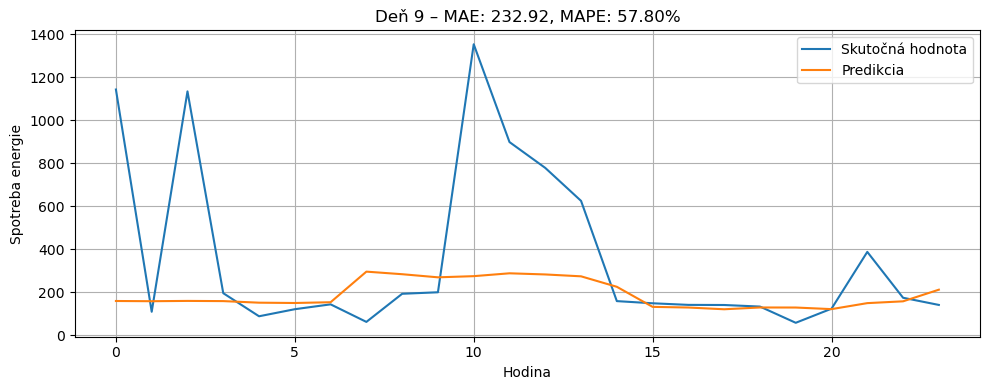

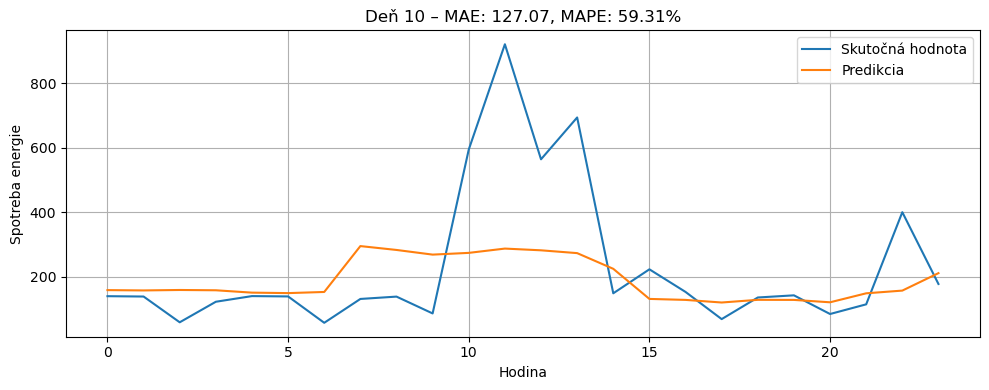

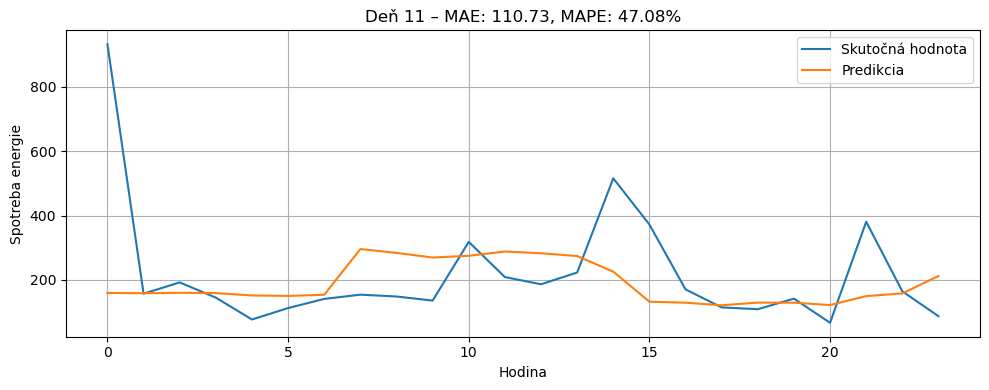

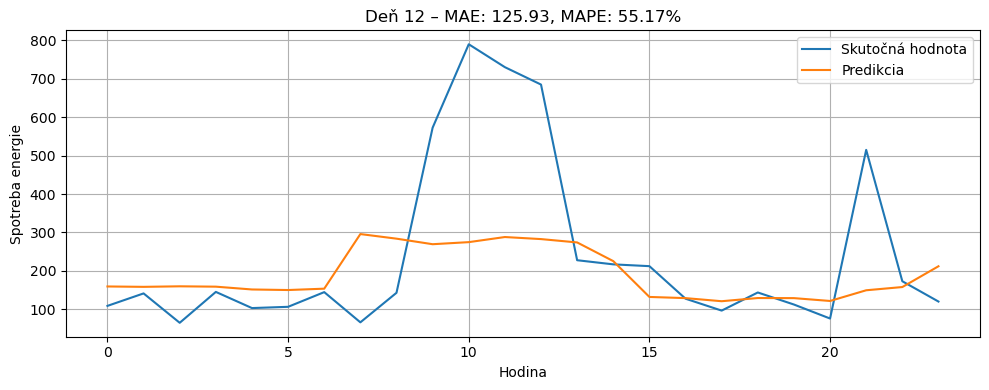

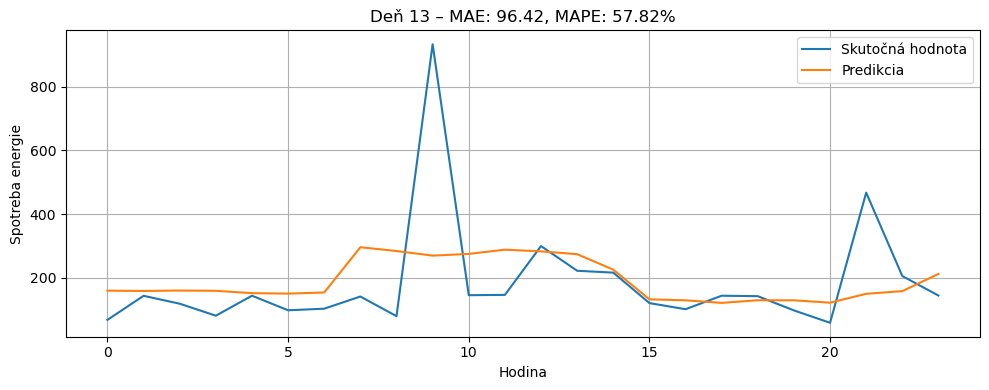

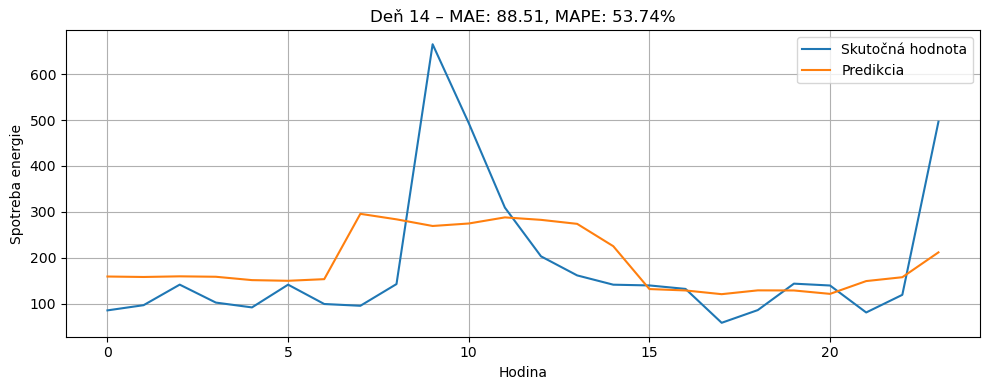

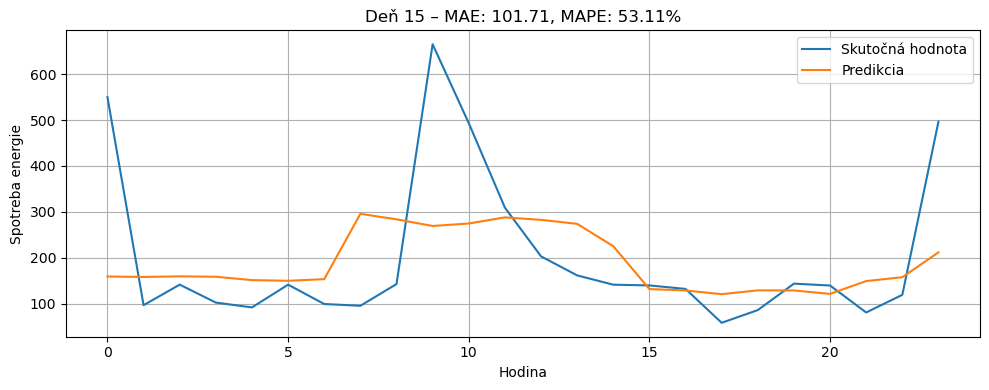

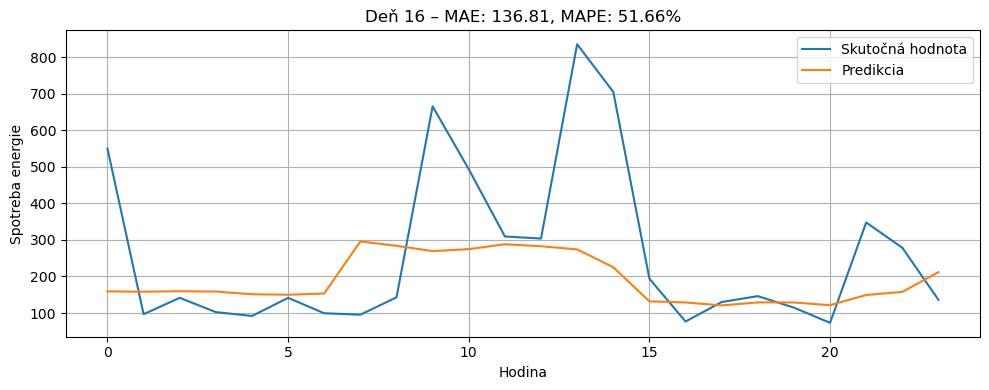

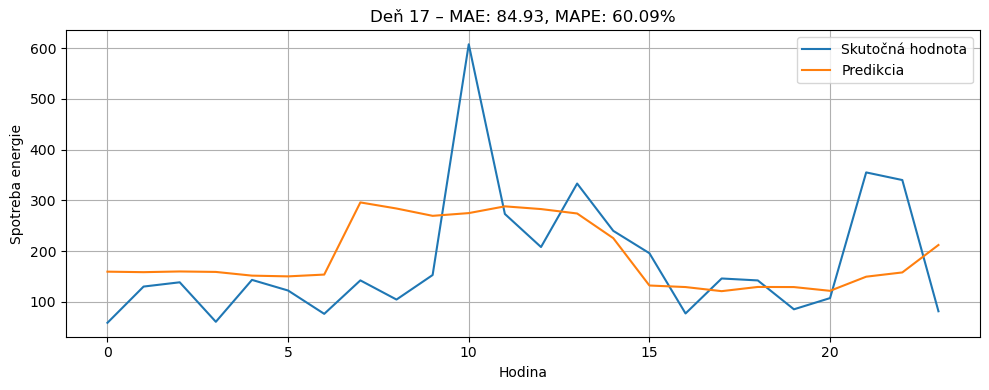

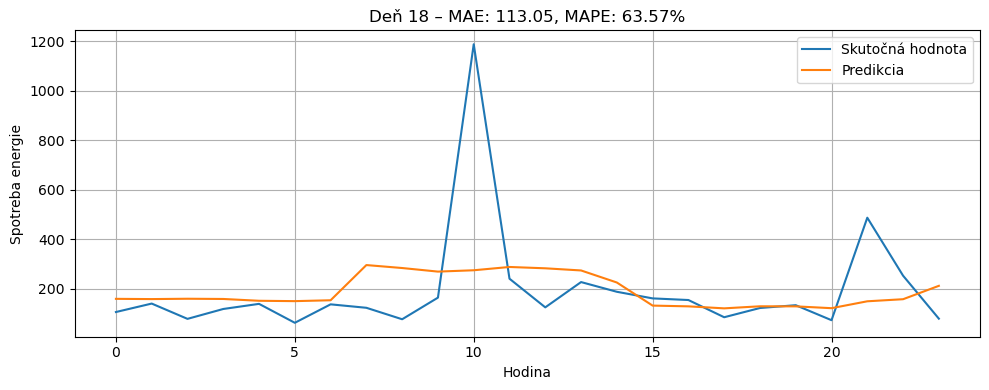

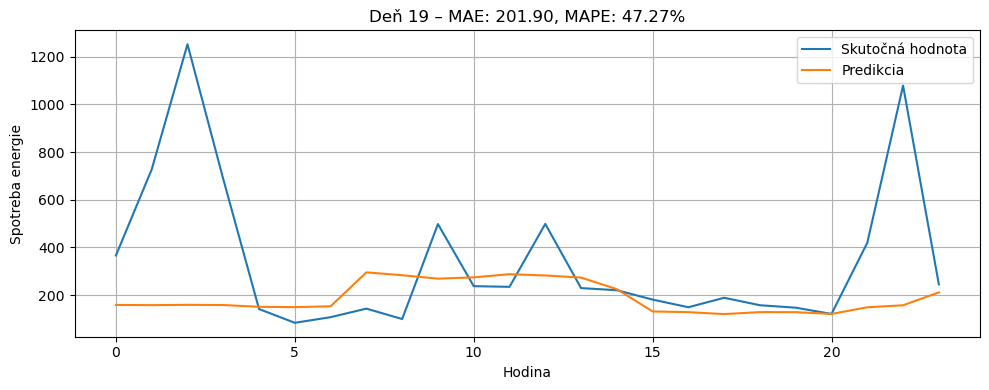

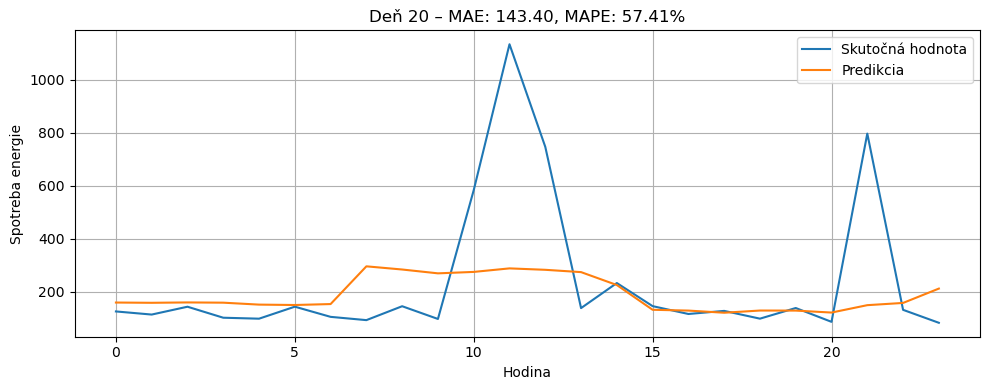

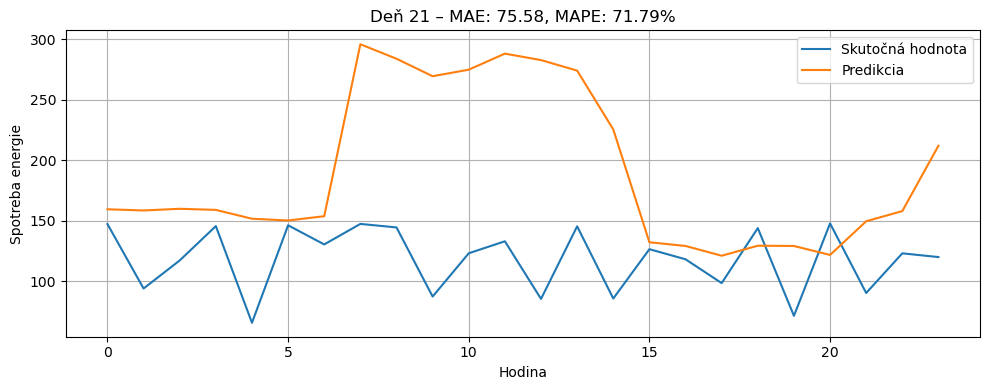

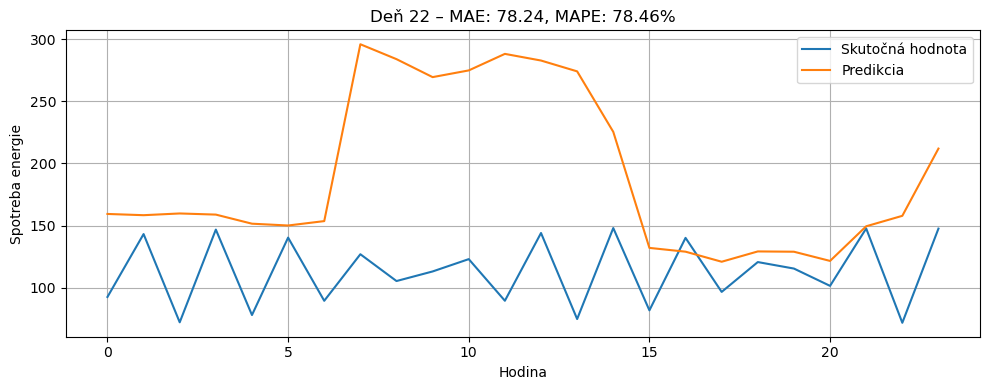

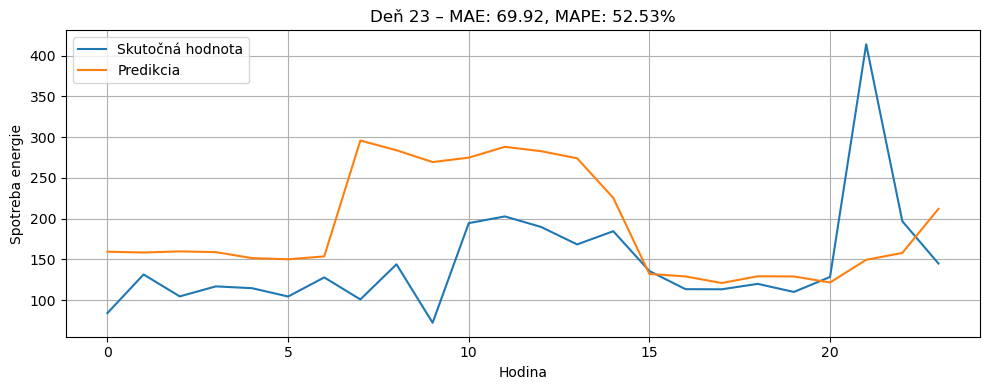

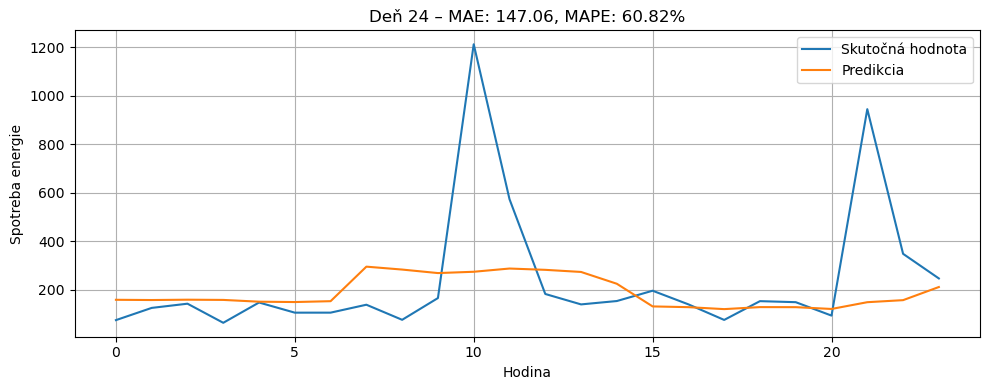

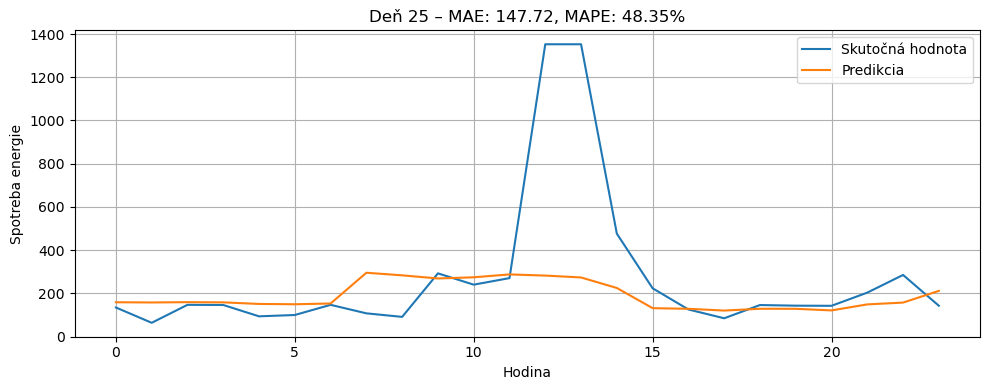

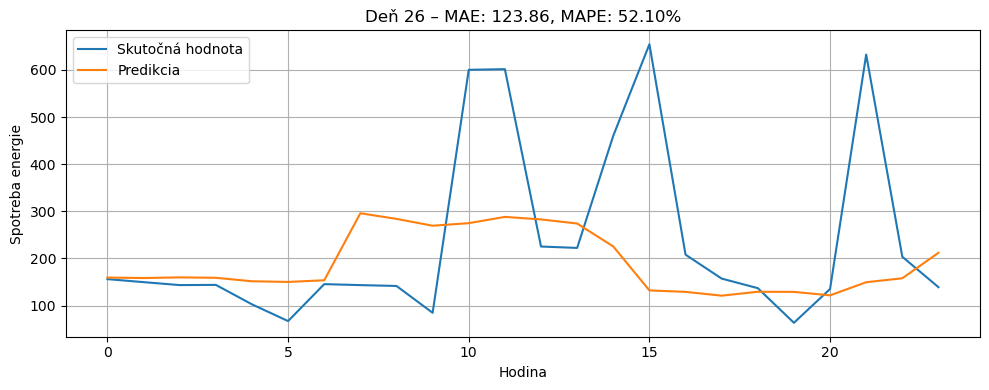

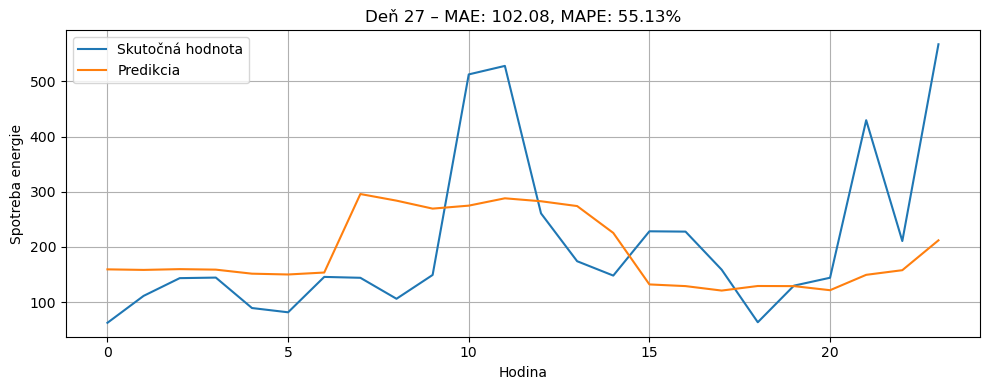

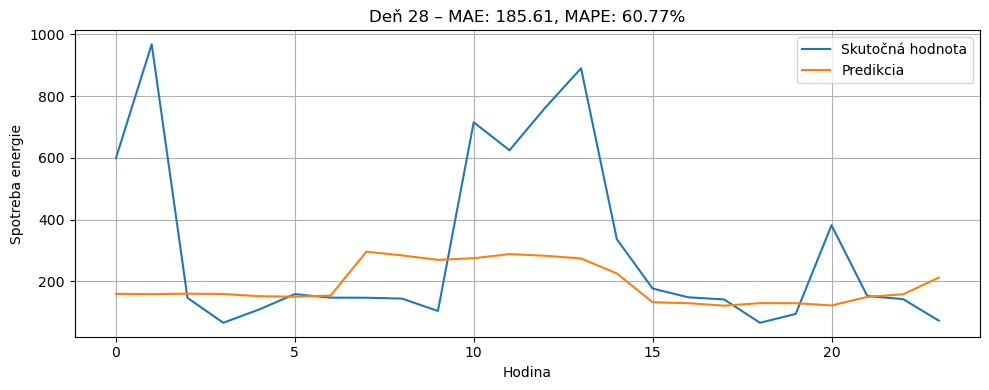

In [33]:
# Načítanie potrebných knižníc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")  # Potlačenie varovaní

# Príprava vstupných a cieľových premenných
features = [col for col in df2.columns if col != 'P_cumulative']  # Všetky vstupy okrem cieľovej premennej
target_col = 'P_cumulative'  # Cieľová premenná – kumulovaná spotreba energie

# Parametre dĺžky trénovacích a testovacích období
train_days = 7
test_days = list(range(8, 29))  # Testovanie na dňoch 8–28

# Definovanie parametrov pre GridSearch
param_grid = {
    'n_estimators': [100, 200],       # Počet stromov
    'learning_rate': [0.01, 0.05],    # Rýchlosť učenia
    'max_depth': [3, 5]               # Hĺbka stromu
}

results = []  # Zoznam pre ukladanie výsledkov
from itertools import product

# GRIDSEARCH: hľadanie najlepšej kombinácie parametrov a začiatku trénovania
for n_estimators, learning_rate, max_depth in product(param_grid['n_estimators'],
                                                       param_grid['learning_rate'],
                                                       param_grid['max_depth']):

    for train_start_day in range(1, 8):  # Skúšame rôzne posuny začiatku trénovania
        mae_list = []
        mape_list = []

        # Výpočet indexov pre tréning a cieľ
        train_start = train_start_day * 24
        train_end = train_start + train_days * 24
        target_start = train_end
        target_end = target_start + 24  # Predikcia na nasledujúci deň

        if target_end > len(df2):
            continue

        # Normalizácia dát
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # Tréningové vstupy a výstupy (1 vzorka = celý deň flattenutý do jedného vektora)
        X_train = scaler_X.fit_transform(df2[features].iloc[train_start:train_end])
        y_train_target = scaler_y.fit_transform(df2[[target_col]].iloc[target_start:target_end])
        X_train_flat = X_train.flatten().reshape(1, -1)

        # Tréning modelu
        model = XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth
        )
        model.fit(X_train_flat, y_train_target.ravel())

        # Testovanie na rôznych dňoch
        for d in test_days:
            x_start = (d - train_days) * 24
            x_end = d * 24
            y_start = d * 24
            y_end = y_start + 24

            if y_end > len(df):
                continue

            # Vytvorenie testovacích vstupov a predikcia
            X_test = scaler_X.transform(df[features].iloc[x_start:x_end]).flatten().reshape(1, -1)
            y_test = scaler_y.transform(df[[target_col]].iloc[y_start:y_end])
            y_test_inv = scaler_y.inverse_transform(y_test).flatten()

            y_pred = model.predict(X_test).reshape(-1, 1)
            y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

            # Výpočet metrík
            mae = mean_absolute_error(y_test_inv, y_pred_inv)
            mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

            mae_list.append(mae)
            mape_list.append(mape)

        # Uloženie výsledkov pre danú kombináciu
        results.append({
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'train_start_day': train_start_day,
            'avg_mae': np.mean(mae_list),
            'min_mae': np.min(mae_list),
            'max_mae': np.max(mae_list),
            'avg_mape': np.mean(mape_list),
            'min_mape': np.min(mape_list),
            'max_mape': np.max(mape_list)
        })

# Vytvorenie DataFrame s výsledkami
df_grid = pd.DataFrame(results)
df_sorted = df_grid.sort_values(by='avg_mae')  # Zoradenie podľa priemerného MAE

# Výpis najlepších výsledkov
print("\nVýsledky GridSearch (zoradené podľa priemerného MAE):")
print(df_sorted)

# Výpis najlepšej kombinácie parametrov
best = df_sorted.iloc[0]
print("\nNajlepšia kombinácia:")
print(f"n_estimators = {best['n_estimators']}")
print(f"learning_rate = {best['learning_rate']}")
print(f"max_depth = {best['max_depth']}")
print(f"train_start_day = {best['train_start_day']}")
print(f"MAE: priemer = {best['avg_mae']:.2f}, min = {best['min_mae']:.2f}, max = {best['max_mae']:.2f}")
print(f"MAPE: priemer = {best['avg_mape']*100:.2f}%, min = {best['min_mape']*100:.2f}%, max = {best['max_mape']*100:.2f}%")

# Tréning finálneho modelu s najlepšími parametrami
best_params = {
    'n_estimators': int(best['n_estimators']),
    'learning_rate': float(best['learning_rate']),
    'max_depth': int(best['max_depth'])
}
train_start_day = int(best['train_start_day'])

# Príprava dát pre finálny model
train_start = train_start_day * 24
train_end = train_start + train_days * 24
target_start = train_end
target_end = target_start + 24

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(df2[features].iloc[train_start:train_end])
y_train = scaler_y.fit_transform(df2[[target_col]].iloc[target_start:target_end])
X_train_flat = X_train.flatten().reshape(1, -1)

model = XGBRegressor(**best_params)
model.fit(X_train_flat, y_train.ravel())

# Testovanie finálneho modelu a vizualizácia predikcie
for d in test_days:
    x_start = (d - train_days) * 24
    x_end = d * 24
    y_start = d * 24
    y_end = y_start + 24

    if y_end > len(df):
        continue

    X_test = scaler_X.transform(df[features].iloc[x_start:x_end]).flatten().reshape(1, -1)
    y_test = scaler_y.transform(df[[target_col]].iloc[y_start:y_end])
    y_test_inv = scaler_y.inverse_transform(y_test).flatten()

    y_pred = model.predict(X_test).reshape(-1, 1)
    y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

    # Vizualizácia výsledkov
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_inv, label='Skutočná hodnota')
    plt.plot(y_pred_inv, label='Predikcia')
    plt.title(f'Deň {d} – MAE: {mae:.2f}, MAPE: {mape*100:.2f}%')
    plt.xlabel('Hodina')
    plt.ylabel('Spotreba energie')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### 14-dňový cyklus


Výsledky GridSearch (zoradené podľa priemerného MAE):
    n_estimators  learning_rate  max_depth  train_start_day     avg_mae  \
1            100           0.01          3                2  119.506888   
8            100           0.01          5                2  119.506888   
2            100           0.01          3                3  121.614424   
9            100           0.01          5                3  121.614424   
36           200           0.01          5                2  121.664452   
29           200           0.01          3                2  121.664452   
0            100           0.01          3                1  123.666968   
7            100           0.01          5                1  123.666968   
35           200           0.01          5                1  123.745432   
28           200           0.01          3                1  123.745432   
37           200           0.01          5                3  123.787663   
30           200           0.01          3   

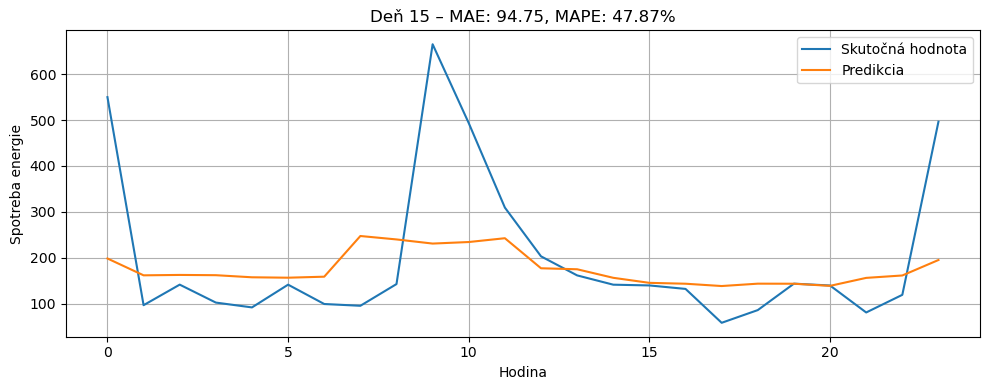

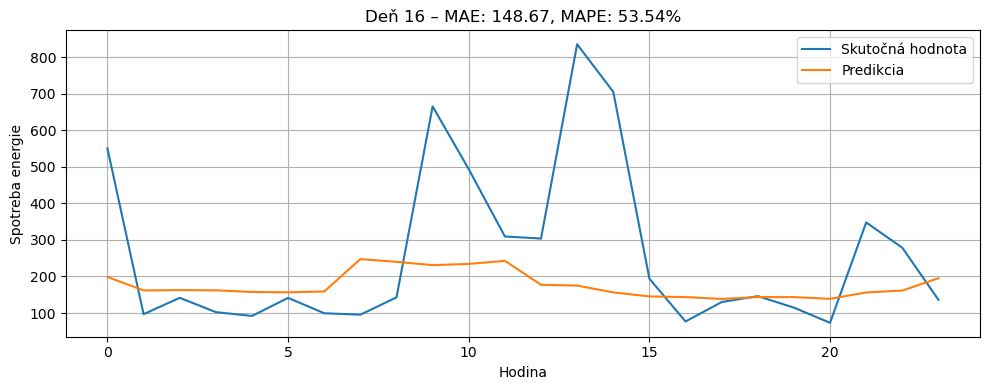

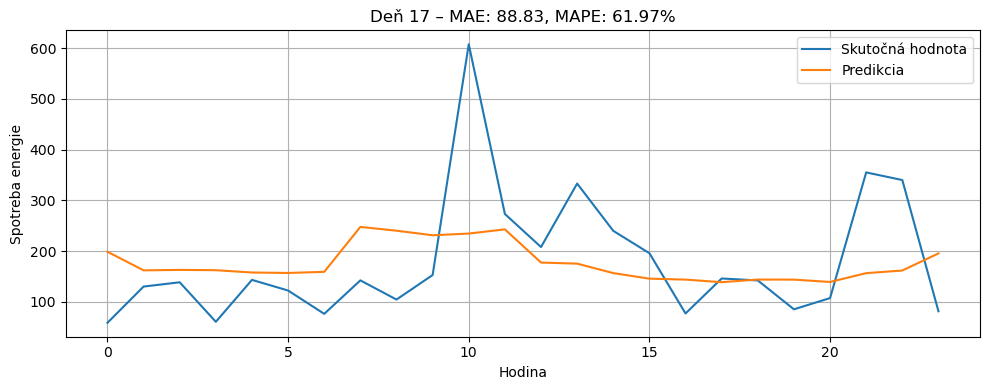

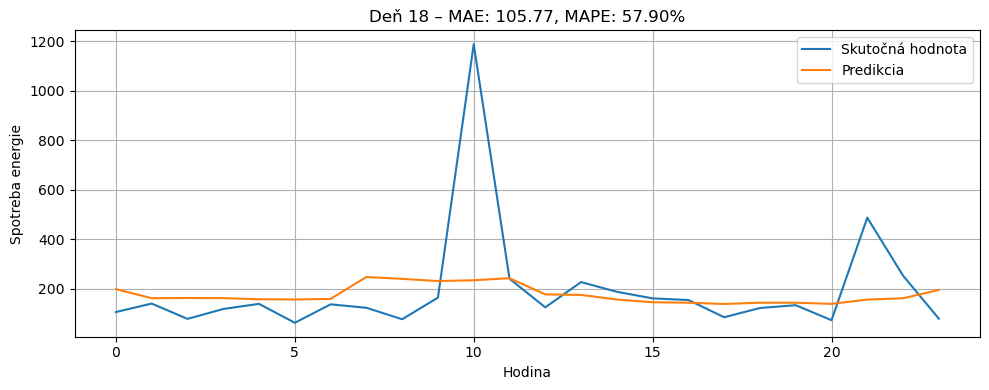

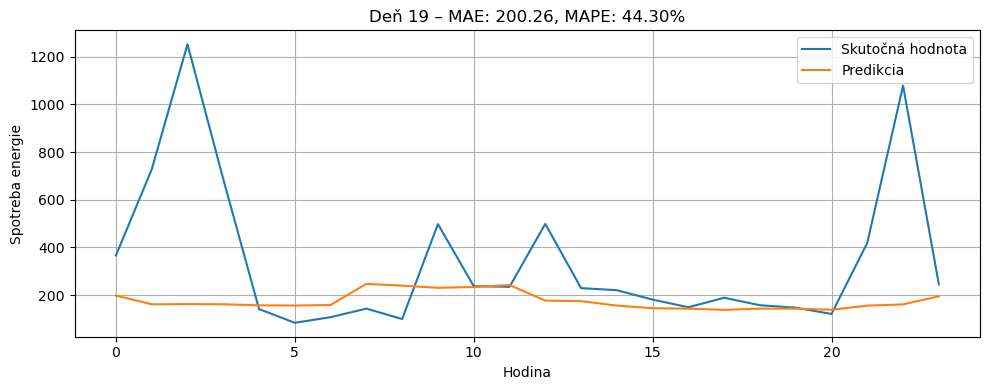

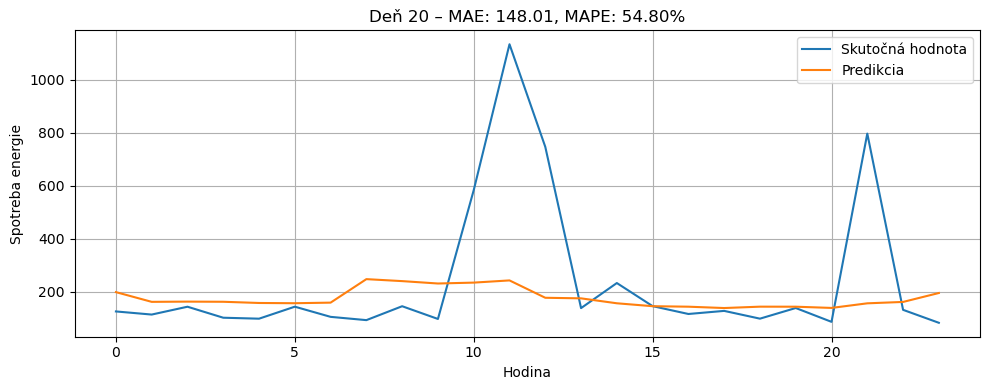

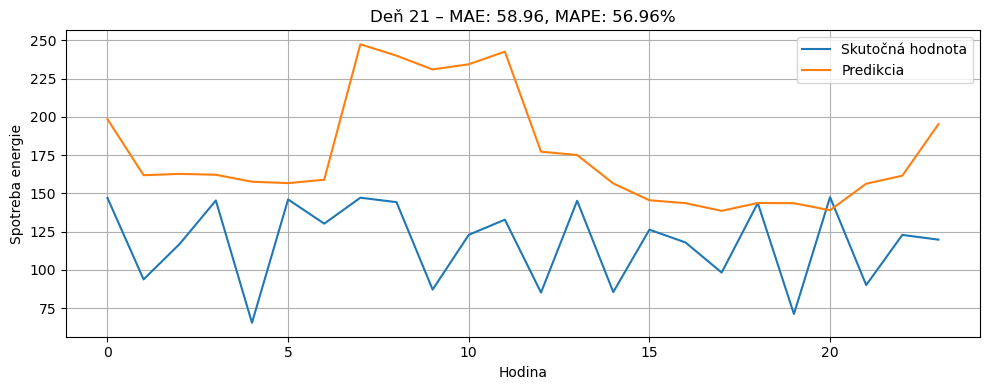

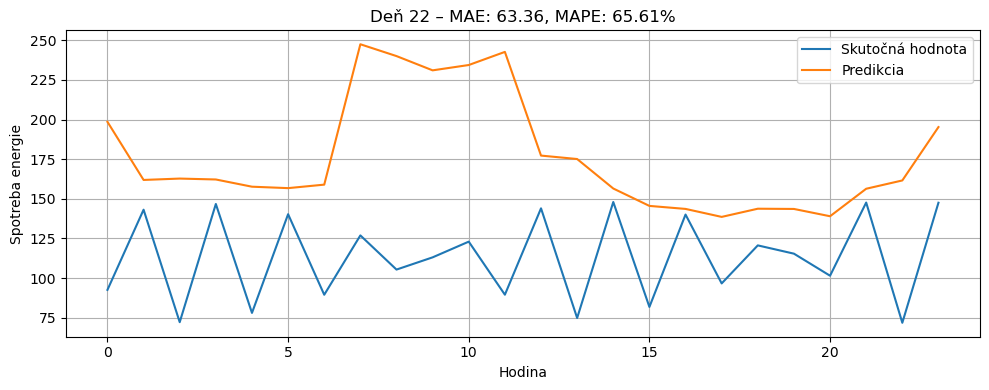

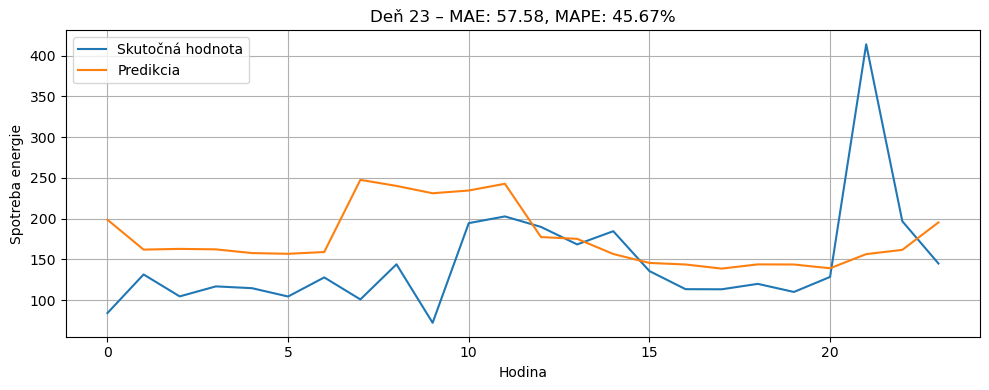

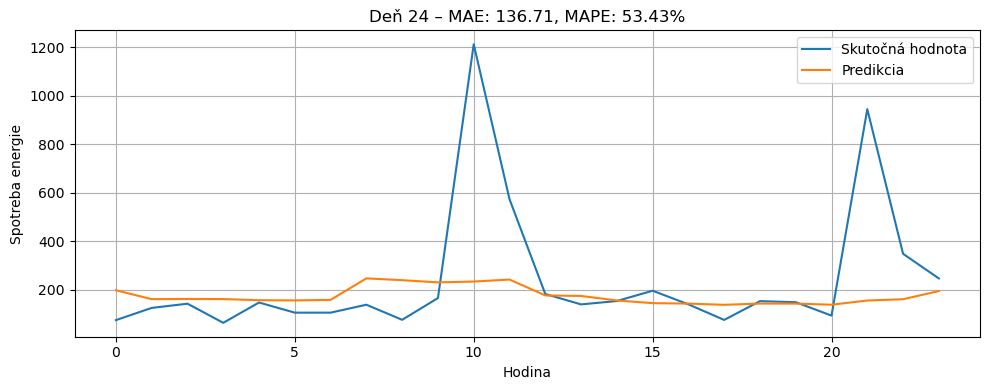

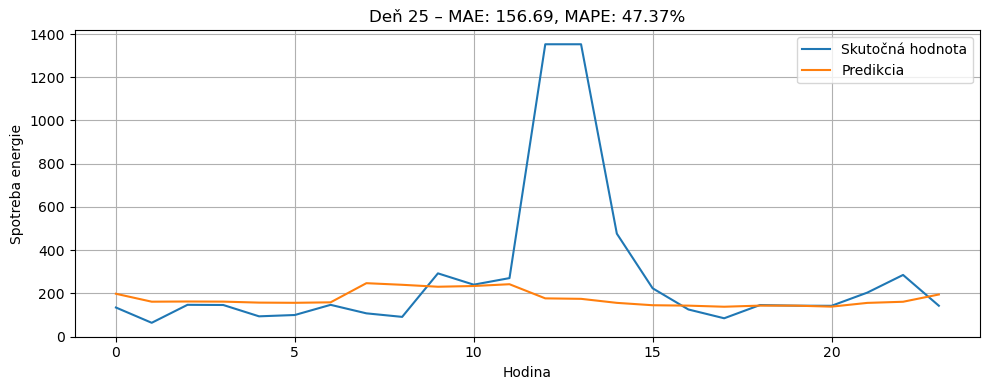

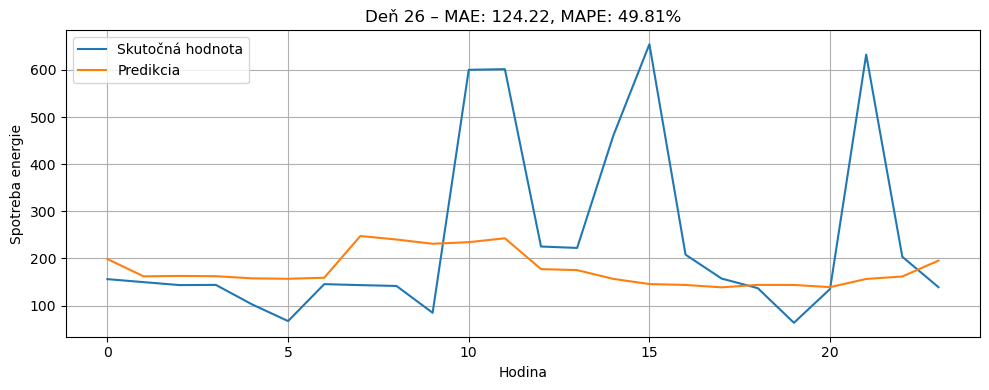

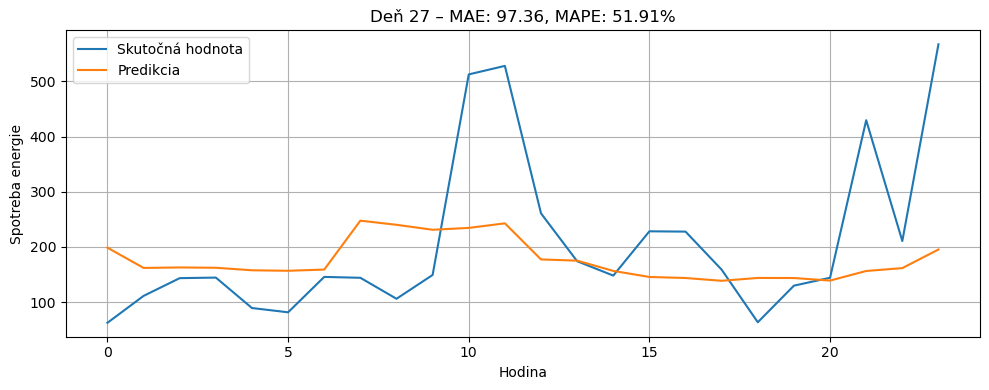

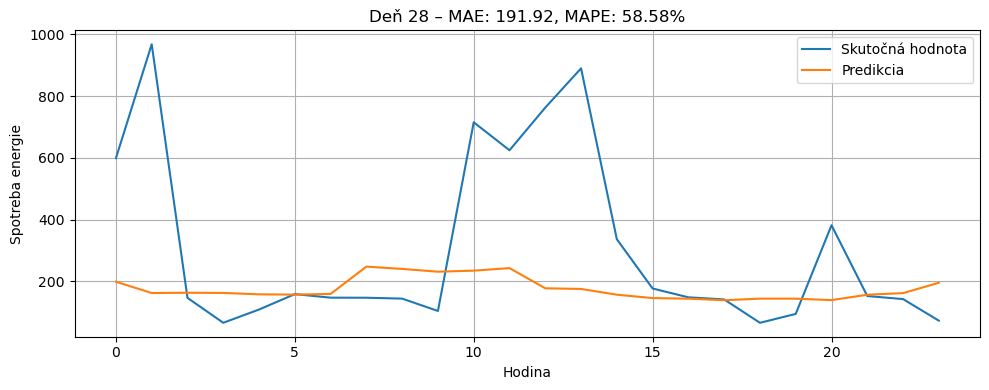

In [37]:
# Import knižníc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")  # Potlačenie varovaní

# Príprava vstupných a výstupných premenných
features = [col for col in df2.columns if col != 'P_cumulative']  # Všetky stĺpce okrem cieľového
target_col = 'P_cumulative'  # Cieľová premenná – kumulovaná spotreba

# Nastavenie dĺžky trénovacích a testovacích období
train_days = 14  # Dvojtýždňový tréning
test_days = list(range(15, 29))  # Testovanie na dňoch 15–28

# Mriežka hyperparametrov pre GridSearch
param_grid = {
    'n_estimators': [100, 200],       # Počet stromov
    'learning_rate': [0.01, 0.05],    # Rýchlosť učenia
    'max_depth': [3, 5]               # Hĺbka stromov
}

results = []  # Zoznam na uchovanie výsledkov
from itertools import product  # Import na generovanie všetkých kombinácií parametrov

# GRIDSEARCH: iterácia cez všetky kombinácie hyperparametrov
for n_estimators, learning_rate, max_depth in product(param_grid['n_estimators'],
                                                       param_grid['learning_rate'],
                                                       param_grid['max_depth']):

    for train_start_day in range(1, 8):  # Skúšanie rôznych posunov začiatku tréningu
        mae_list = []
        mape_list = []

        # Výpočet indexov pre tréning a predikciu
        train_start = train_start_day * 24
        train_end = train_start + train_days * 24
        target_start = train_end
        target_end = target_start + 24  # Predikcia na nasledujúci deň

        if target_end > len(df2):
            continue  # Preskočí, ak by sa prekročili dáta

        # Normalizácia vstupov a cieľa
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # Príprava trénovacích dát (celý deň ako jedna vzorka)
        X_train = scaler_X.fit_transform(df2[features].iloc[train_start:train_end])
        y_train_target = scaler_y.fit_transform(df2[[target_col]].iloc[target_start:target_end])
        X_train_flat = X_train.flatten().reshape(1, -1)

        # Tréning modelu s danými hyperparametrami
        model = XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth
        )
        model.fit(X_train_flat, y_train_target.ravel())

        # Testovanie na viacerých dňoch
        for d in test_days:
            x_start = (d - train_days) * 24
            x_end = d * 24
            y_start = d * 24
            y_end = y_start + 24

            if y_end > len(df):
                continue  # Preskočí, ak nemáme dostatok dát

            # Vytvorenie testovacej vzorky
            X_test = scaler_X.transform(df[features].iloc[x_start:x_end]).flatten().reshape(1, -1)
            y_test = scaler_y.transform(df[[target_col]].iloc[y_start:y_end])
            y_test_inv = scaler_y.inverse_transform(y_test).flatten()  # Skutočné hodnoty

            # Predikcia a spätná transformácia
            y_pred = model.predict(X_test).reshape(-1, 1)
            y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

            # Výpočet chýb
            mae = mean_absolute_error(y_test_inv, y_pred_inv)
            mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

            mae_list.append(mae)
            mape_list.append(mape)

        # Uloženie výsledkov pre danú konfiguráciu
        results.append({
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'train_start_day': train_start_day,
            'avg_mae': np.mean(mae_list),
            'min_mae': np.min(mae_list),
            'max_mae': np.max(mae_list),
            'avg_mape': np.mean(mape_list),
            'min_mape': np.min(mape_list),
            'max_mape': np.max(mape_list)
        })

# Vytvorenie tabuľky výsledkov
df_grid = pd.DataFrame(results)
df_sorted = df_grid.sort_values(by='avg_mae')  # Zoradenie podľa priemerného MAE

# Výpis zoradených výsledkov
print("\nVýsledky GridSearch (zoradené podľa priemerného MAE):")
print(df_sorted)

# Výpis najlepšej kombinácie
best = df_sorted.iloc[0]
print("\nNajlepšia kombinácia:")
print(f"n_estimators = {best['n_estimators']}")
print(f"learning_rate = {best['learning_rate']}")
print(f"max_depth = {best['max_depth']}")
print(f"train_start_day = {best['train_start_day']}")
print(f"MAE: priemer = {best['avg_mae']:.2f}, min = {best['min_mae']:.2f}, max = {best['max_mae']:.2f}")
print(f"MAPE: priemer = {best['avg_mape']*100:.2f}%, min = {best['min_mape']*100:.2f}%, max = {best['max_mape']*100:.2f}%")

# TRÉNING finálneho modelu s najlepšími parametrami
best_params = {
    'n_estimators': int(best['n_estimators']),
    'learning_rate': float(best['learning_rate']),
    'max_depth': int(best['max_depth'])
}
train_start_day = int(best['train_start_day'])

# Príprava tréningových dát pre finálny model
train_start = train_start_day * 24
train_end = train_start + train_days * 24
target_start = train_end
target_end = target_start + 24

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(df2[features].iloc[train_start:train_end])
y_train = scaler_y.fit_transform(df2[[target_col]].iloc[target_start:target_end])
X_train_flat = X_train.flatten().reshape(1, -1)

# Tréning finálneho modelu
model = XGBRegressor(**best_params)
model.fit(X_train_flat, y_train.ravel())

# TESTOVANIE finálneho modelu s vizualizáciou
for d in test_days:
    x_start = (d - train_days) * 24
    x_end = d * 24
    y_start = d * 24
    y_end = y_start + 24

    if y_end > len(df):
        continue

    X_test = scaler_X.transform(df[features].iloc[x_start:x_end]).flatten().reshape(1, -1)
    y_test = scaler_y.transform(df[[target_col]].iloc[y_start:y_end])
    y_test_inv = scaler_y.inverse_transform(y_test).flatten()

    y_pred = model.predict(X_test).reshape(-1, 1)
    y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

    # Zobrazenie grafu výsledkov pre každý deň
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_inv, label='Skutočná hodnota')
    plt.plot(y_pred_inv, label='Predikcia')
    plt.title(f'Deň {d} – MAE: {mae:.2f}, MAPE: {mape*100:.2f}%')
    plt.xlabel('Hodina')
    plt.ylabel('Spotreba energie')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### 21-dňový cyklus


Výsledky GridSearch (zoradené podľa priemerného MAE):
    n_estimators  learning_rate  max_depth  train_start_day     avg_mae  \
2            100           0.01          3                3  117.584752   
9            100           0.01          5                3  117.584752   
12           100           0.01          5                6  119.927837   
5            100           0.01          3                6  119.927837   
3            100           0.01          3                4  121.764370   
10           100           0.01          5                4  121.764370   
37           200           0.01          5                3  122.308063   
30           200           0.01          3                3  122.308063   
4            100           0.01          3                5  122.378912   
11           100           0.01          5                5  122.378912   
33           200           0.01          3                6  123.108034   
40           200           0.01          5   

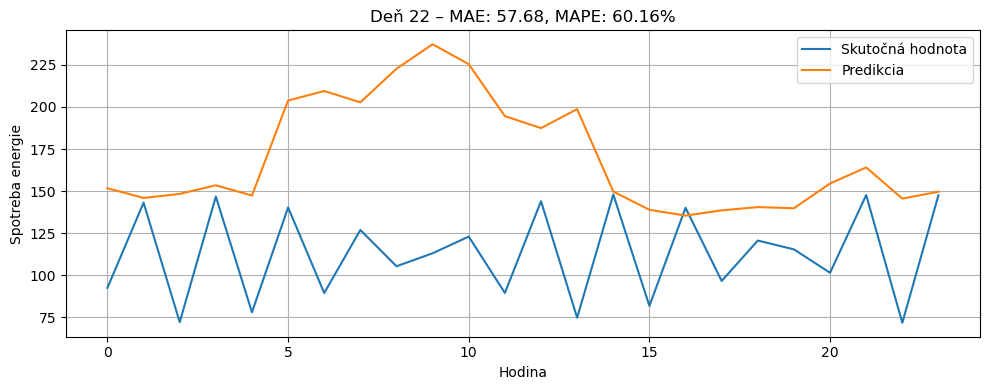

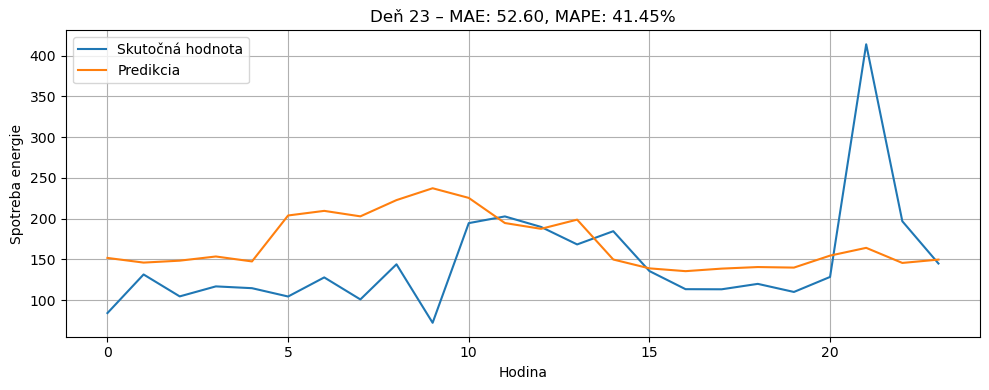

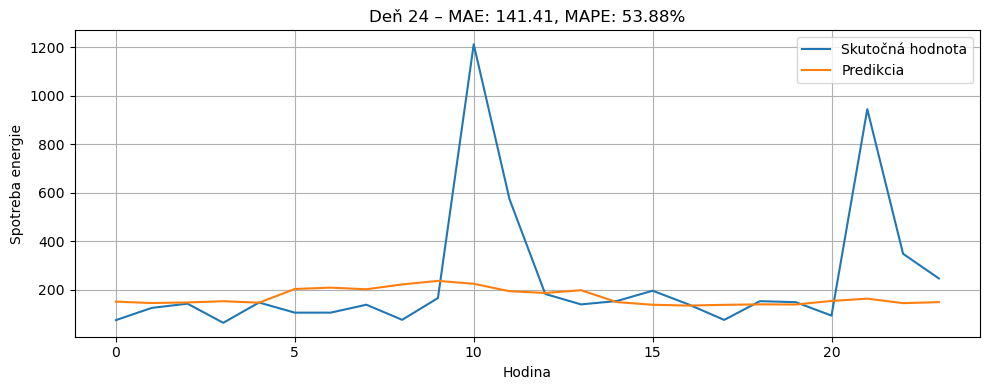

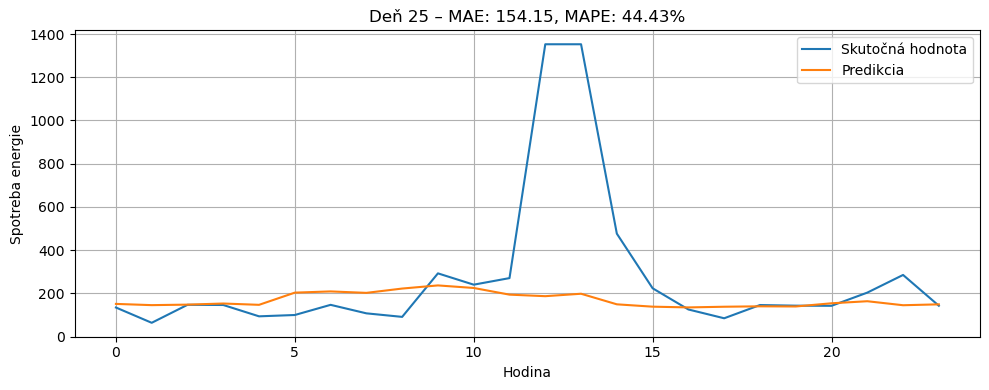

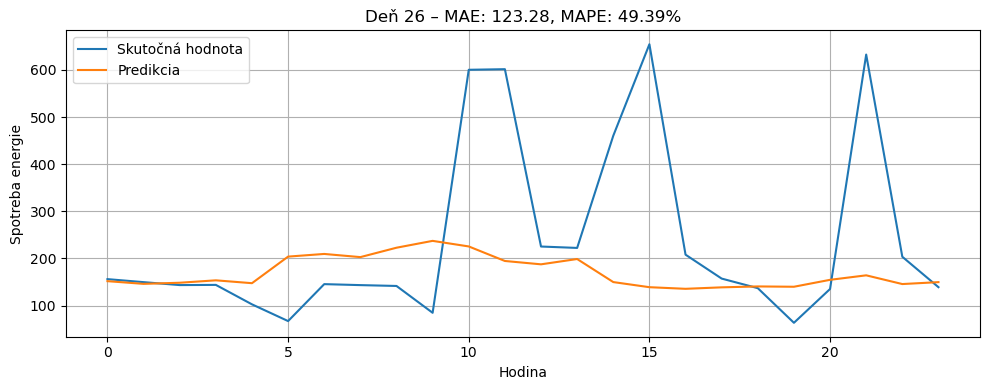

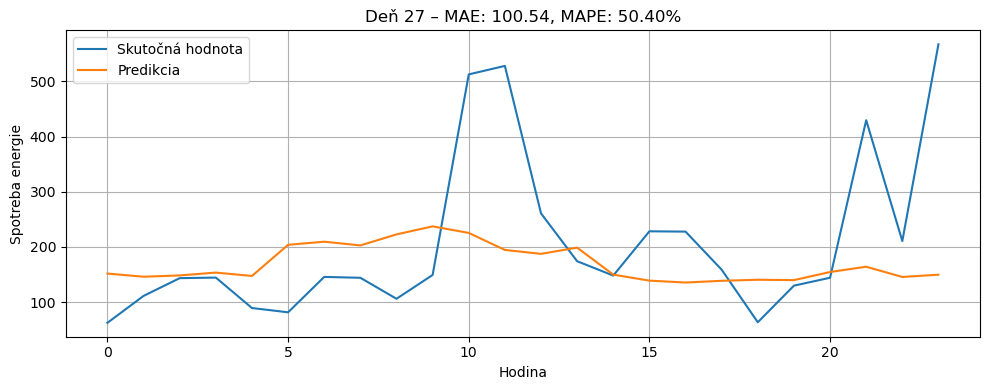

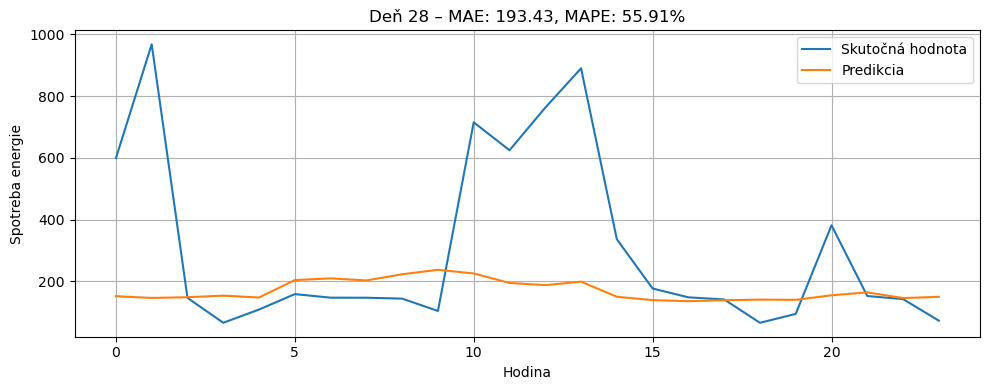

In [39]:
# Import knižníc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")  # Potlačenie varovaní pre čistejší výstup

# Príprava dát – výber vstupov a cieľovej premennej
features = [col for col in df2.columns if col != 'P_cumulative']  # Všetky stĺpce okrem cieľového
target_col = 'P_cumulative'  # Cieľová premenná: celková spotreba energie

# Definovanie dĺžky tréningu a testovacie dni
train_days = 21
test_days = list(range(22, 29))  # Testujeme na dňoch 22 až 28

# Definícia parametrov pre GridSearch
param_grid = {
    'n_estimators': [100, 200],       # Počet stromov v modeli
    'learning_rate': [0.01, 0.05],    # Krok učenia
    'max_depth': [3, 5]               # Hĺbka každého stromu
}

results = []  # Pole na uloženie výsledkov
from itertools import product  # Import pre vytvorenie všetkých kombinácií parametrov

# GRIDSEARCH: iterovanie cez všetky kombinácie parametrov
for n_estimators, learning_rate, max_depth in product(param_grid['n_estimators'],
                                                       param_grid['learning_rate'],
                                                       param_grid['max_depth']):

    for train_start_day in range(1, 8):  # Posuny začiatku trénovania od dňa 1 do 7
        mae_list = []
        mape_list = []

        # Výpočet indexov pre tréningové a cieľové okno
        train_start = train_start_day * 24
        train_end = train_start + train_days * 24
        target_start = train_end
        target_end = target_start + 24  # Predikcia na nasledujúci deň

        if target_end > len(df2):
            continue  # Preskočí, ak chýbajú dáta

        # Normalizácia vstupných a cieľových údajov
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # Príprava trénovacích dát (1 vzorka = 21 dní, každý deň po 24 hodín, flattenutý)
        X_train = scaler_X.fit_transform(df2[features].iloc[train_start:train_end])
        y_train_target = scaler_y.fit_transform(df2[[target_col]].iloc[target_start:target_end])
        X_train_flat = X_train.flatten().reshape(1, -1)

        # Vytvorenie a trénovanie modelu
        model = XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth
        )
        model.fit(X_train_flat, y_train_target.ravel())

        # Testovanie na jednotlivých dňoch
        for d in test_days:
            x_start = (d - train_days) * 24
            x_end = d * 24
            y_start = d * 24
            y_end = y_start + 24

            if y_end > len(df):
                continue  # Ak by chýbali dáta, preskočí

            # Príprava testovacích vstupov a skutočných výstupov
            X_test = scaler_X.transform(df[features].iloc[x_start:x_end]).flatten().reshape(1, -1)
            y_test = scaler_y.transform(df[[target_col]].iloc[y_start:y_end])
            y_test_inv = scaler_y.inverse_transform(y_test).flatten()

            # Predikcia a spätná transformácia
            y_pred = model.predict(X_test).reshape(-1, 1)
            y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

            # Výpočet metrík
            mae = mean_absolute_error(y_test_inv, y_pred_inv)
            mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

            mae_list.append(mae)
            mape_list.append(mape)

        # Uloženie priemerov pre danú kombináciu parametrov
        results.append({
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'train_start_day': train_start_day,
            'avg_mae': np.mean(mae_list),
            'min_mae': np.min(mae_list),
            'max_mae': np.max(mae_list),
            'avg_mape': np.mean(mape_list),
            'min_mape': np.min(mape_list),
            'max_mape': np.max(mape_list)
        })

# Vytvorenie tabuľky výsledkov
df_grid = pd.DataFrame(results)
df_sorted = df_grid.sort_values(by='avg_mae')  # Zoradenie podľa MAE

# Výpis všetkých kombinácií
print("\nVýsledky GridSearch (zoradené podľa priemerného MAE):")
print(df_sorted)

# Najlepšia kombinácia parametrov
best = df_sorted.iloc[0]
print("\nNajlepšia kombinácia:")
print(f"n_estimators = {best['n_estimators']}")
print(f"learning_rate = {best['learning_rate']}")
print(f"max_depth = {best['max_depth']}")
print(f"train_start_day = {best['train_start_day']}")
print(f"MAE: priemer = {best['avg_mae']:.2f}, min = {best['min_mae']:.2f}, max = {best['max_mae']:.2f}")
print(f"MAPE: priemer = {best['avg_mape']*100:.2f}%, min = {best['min_mape']*100:.2f}%, max = {best['max_mape']*100:.2f}%")

# TRÉNING finálneho modelu s najlepšími parametrami
best_params = {
    'n_estimators': int(best['n_estimators']),
    'learning_rate': float(best['learning_rate']),
    'max_depth': int(best['max_depth'])
}
train_start_day = int(best['train_start_day'])

# Výpočet indexov pre tréning a cieľ
train_start = train_start_day * 24
train_end = train_start + train_days * 24
target_start = train_end
target_end = target_start + 24

# Normalizácia finálnych tréningových údajov
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(df2[features].iloc[train_start:train_end])
y_train = scaler_y.fit_transform(df2[[target_col]].iloc[target_start:target_end])
X_train_flat = X_train.flatten().reshape(1, -1)

# Tréning finálneho modelu
model = XGBRegressor(**best_params)
model.fit(X_train_flat, y_train.ravel())

# TESTOVANIE finálneho modelu s grafickým výstupom
for d in test_days:
    x_start = (d - train_days) * 24
    x_end = d * 24
    y_start = d * 24
    y_end = y_start + 24

    if y_end > len(df):
        continue

    # Príprava testovacích dát
    X_test = scaler_X.transform(df[features].iloc[x_start:x_end]).flatten().reshape(1, -1)
    y_test = scaler_y.transform(df[[target_col]].iloc[y_start:y_end])
    y_test_inv = scaler_y.inverse_transform(y_test).flatten()

    # Predikcia
    y_pred = model.predict(X_test).reshape(-1, 1)
    y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

    # Vizualizácia výsledkov
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_inv, label='Skutočná hodnota')
    plt.plot(y_pred_inv, label='Predikcia')
    plt.title(f'Deň {d} – MAE: {mae:.2f}, MAPE: {mape*100:.2f}%')
    plt.xlabel('Hodina')
    plt.ylabel('Spotreba energie')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
